# Fourier Transform Demo: Periodic Neural Dynamics

This notebook walks through a simple example of applying the Fourier transform to calcium imaging data.
The goal is to show how stimulus-driven neuronal responses can be identified at a stimulus-locked frequency, along with brief analysis of the result. If you are unfamiliar with Fourier Transformation, you could check the Intro_Fourier_Transformation notebook, where I introduce basic concept of Fourier Transformation

The dataset in `/data` serves as an example; in practice, the same pipeline can be applied to other experimental recordings with slight variation.

Prefer not to run cells by hand? `demo/run_fish6_pipeline.py` runs this exact pipeline start to finish as a script and saves every figure automatically.

The calcium imaging data comes from zebrafish performing phototaxis, the tendency of zebrafish to orient toward illumination. Phototaxis behavior was elicited in this dataset by a periodic half-field dark stimulus (more detail can be found in [original Neuron paper](<https://www.cell.com/neuron/pdf/S0896-6273(18)30844-4.pdf>)). The periodicity of the stimulus makes it suitable for Fourier analysis.


## Table of Content
#### Step 0: Setup Instructions
#### Step 1: Identifying Periodic Properties in the Stimulus Signal
#### Step 2: Identification of sensory neurons by Fourier Transformation
- Step 2.1: Loading Neuron Activity Data
- Step 2.2: Example Case — Extracting Periodic Neural Activity via Fourier Transformation
- Step 2.3: Identify Stimulus-Locked Neurons from Fourier Results
#### Step 3: Selecting Stimulus-Locked Neurons Based on Phase and Amplitude
- Step 3.1: Selection Criterion 1 — Amplitude Threshold
- Step 3.2: Selection Criterion 2 — Phase Constraint
#### Step 4: Spatial Mapping of Stimulus-Locked Neurons
- Step 4.1: Spatial visualization of stimulus-locked neurons
- Step 4.2: Phase-based Spatial Mapping of Neuronal Activation
- Step 4.3: Temporal Sequencing and Laterality of Neuron Response
#### Step 5: Validating Fourier Analysis with Regression Analysis
- Step 5.1: Generate Stimulus Regressor
- Step 5.2: Correlate Each Neuron with the Stimulus Regressor
- Step 5.3: Reproducing Figure 8 — Fourier Properties of Regression-Identified Neurons
- Step 5.4: Spatial Map of Regression-Identified Neurons (Supplementary)
#### Step 6: Comparing Fourier-Identified and Regression-Identified Neurons
#### Step 7: Accuracy of Fourier Analysis Across Amplitude Cutoffs
#### Summary

# Step 0: Setup Instructions

This notebook is self-contained and will help you set up everything needed.

**How to use:**
1. Create a project folder on your computer, with:
   - a `data/` folder for datasets
   - a `notebooks/` folder for this notebook
   - `demo_functions.py` for functions
   - a `images/` folder for images
   - `requirements.txt` for dependencies
2. Open a terminal in the project folder.
3. Create and activate a virtual environment.
4. Install dependencies.
5. Launch Jupyter Notebook and open this file.

No prior setup is required beyond having Python installed. Execute the next code cell in PowerShell or Command Prompt to create the environment


```bash
# Step 1) Navigate to the project folder
cd path\to\your\project

# Step 2) Create a new environment named venv
python -m venv venv

# Step 3) Activate the environment
# PowerShell:
.\venv\Scripts\Activate.ps1
# Or in Command Prompt (cmd.exe):
venv\Scripts\activate.bat

# Step 4) Install the required dependencies
pip install -r requirements.txt

# Step 5) Launch Jupyter Notebook
python -m jupyter notebook

```

### Next steps inside Jupyter
- In the browser window that opens, navigate to the `notebooks/` folder.
- Open `Fourier_Analysis_Demo.ipynb`.
- Ensure the kernel is set to the environment you just created (look for `(venv)` in the kernel name).
- Run the cells step by step to reproduce the analysis.

The next block fetch the directory, please check if the path for Project roots and Data folder are correct

In [ ]:
# Import required dependencies
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import h5py
import scipy

# Get the project root (assume the notebook lives inside /notebooks)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Make sure demo_functions.py (in the project root) is importable regardless of
# where the notebook kernel's working directory happens to be.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Define data folder
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)

# Check that the folder exists
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"❌ Data folder not found at {DATA_DIR}. "
        "Please make sure you have a 'data' folder in your project root."
    )


# Step 1: Identifying Periodic Properties in the Stimulus Signal
*Corresponds to Figure 1 in the manuscript.*

In this section, we analyze the **phototaxis stimulus pattern**.
Because the stimulus was designed to be periodic, we can extract key properties such as its **frequency (or wavelength)** and **phase**.

These properties serve as selection criteria for identifying neurons whose activity patterns closely match the periodic structure of the stimulus. Such neurons are referred to as **stimulus-locked neurons**, and we assume that at least a subset of them are directly involved in the sensory processing of the stimulation.

Run the following code block to load the stimulus data, which can be found in the `/data/stimulus` file.




In [2]:
# read the stimulus data
stimulus = pd.read_excel(
    DATA_DIR / "stimulus.xlsx",
    header=None
).to_numpy()[0]

# Represent left/right stimulus by box-car functions
stimulus_right = list([1 if x == 1 else 0 for x in stimulus])
stimulus_left = list([1 if x == 2 else 0 for x in stimulus])

The arrays above represent the **left- and right-sided phototaxis stimuli** as boxcar functions.
- A **right-sided phototaxis stimulus** means the **left side of the fish is dark** while the **right side is illuminated**. Conversely, a **left-sided phototaxis stimulus** means the right side is dark and the left side is illuminated.

Each array element corresponds to the **stimulus status at a given frame** (sampling rate ≈ 1.97 Hz).
- A value of **1** indicates the stimulus was present.
- A value of **0** indicates the stimulus was absent.
- Because the sampling rate is not an exact integer, we use **frame index** (rather than seconds) as the time unit for analysis.

To visualize the stimulus signal pattern for the first 500 frames as a box-car function, run the following code cell.


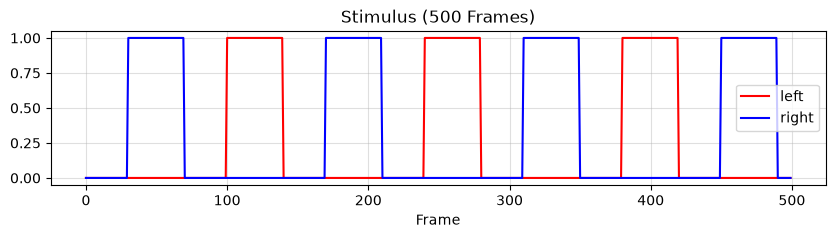

In [3]:
#Visualize the stimulus signal for first 500 frames
plt.figure(figsize=(10,2))
plt.plot(stimulus_left[:500],c = "red")
plt.plot(stimulus_right[:500],c = "blue")
plt.xlabel("Frame")
plt.grid(alpha = 0.4)
plt.title("Stimulus (500 Frames)")
plt.legend(["left", "right"])
plt.show()

![Stimulus diagram](../images/stimulus.png)

**Figure:** Schematic representation of the phototaxis stimulation provided to the fish.
Dark blocks indicate a half-field dark stimulus on the corresponding side.

The stimulus paradigm is **periodic**, consisting of repeated **cycles** of **140 frames** each.
Within each cycle, the fish experienced two phototaxis stimuli, each lasting **40 frames**:
- a **right-sided stimulus** from **Frame 30–70**, and
- a **left-sided stimulus** from **Frame 100–140**.

From this paradigm, we define the following criteria for identifying **stimulus-locked neurons**:
- The neuron’s activity contains a periodic component with a **wavelength of 140 frames** (equivalently, a **frequency of 1/140 Hz**) that matches the stimulus periodicity.
- The neuron’s activity contains a periodic component whose **phase** aligns with the stimulus presentation windows, i.e., **Frame 30–70** (right) or **Frame 100–140** (left).



# Step 2: Identification of sensory neurons by Fourier Transformation
*Corresponds to Figure 1 in the manuscript.*

Now, we would like to perform **Discrete Fourier Transformation** on the neuron activity data and select neurons that match with the selection criteria we outlined previously.



## Step 2.1: Loading Neuron Activity Data

We begin by loading the **neuron activity data**. The example dataset used in this notebook comes from a **public zebrafish whole-brain calcium imaging dataset**. Specifically, we use **Fish_6**, which is also the example shown in the figures of the [original Neuron paper](<https://www.cell.com/neuron/pdf/S0896-6273%2818%2930844-4.pdf>).

This dataset contains activity traces from approximately **100,000 neurons** recorded over **~4,000 frames** at a sampling rate of **1.97 Hz**. Each trace represents the standardized **z-scored ΔF/F fluorescence signal** of an individual neuron.

Due to the file size, please download the raw data **'CellRespZ.h5'** (~1.3GB) by running the following code cell. Or download it manually from [google drive](<https://drive.google.com/file/d/11j_hQXRwY7URa9UnZYo6vAYR5TWLgHGj/view?usp=sharing>) and put it in the `/data/` folder under the project folder.



In [ ]:
import gdown
dest_file = DATA_DIR / "CellRespZ.h5"

# Google Drive link
url = "https://drive.google.com/uc?export=download&id=11j_hQXRwY7URa9UnZYo6vAYR5TWLgHGj"

# Check if file already exists
if dest_file.exists():
    print(f"✅ Found dataset at {dest_file}, skipping download.")
else:
    print(f"⬇️ Downloading dataset to {dest_file} ...")
    gdown.download(url, str(dest_file), quiet=False)
    print("✅ Download complete!")

Run the following code cell to load the neuron activity data, as well as the corresponding coordinate data.

In [5]:
with h5py.File(DATA_DIR / "CellRespZ.h5", 'r') as f:
    # Access the dataset 'CellRespZ'
    cell_resp_z = f['CellRespZ'][()]

#Read the corresponding position index
absIX = pd.read_excel(DATA_DIR /"absIX.xlsx")
absIX = absIX["neuron_index"].to_numpy().T

data = pd.read_excel(
    DATA_DIR / "CellXYZnorm.xlsx",
    header=None
).to_numpy()

coordinate = [data[i] for i in absIX]

print(f'The shape of loaded data is {cell_resp_z.shape},The correct shape is (92538,3780).')

The shape of loaded data is (92538, 3780),The correct shape is (92538,3780).


To make neuron indexing easier, we add a column which encodes each neuron's original index within the dataset in cell response z-score and coordinates.

Before indexing, we check the shape of neuron activity data to see if the data are loaded correctly. The neuron activity data should be an array shape (92538,3780)

Run the following code cell to add the indexing column.

In [6]:
#Add index column for each data
cell_resp_z = [[i, x] for i, x in enumerate(cell_resp_z)]
coordinate = [[i, x] for i, x in enumerate(coordinate)]

Now the neuron activity data is ready, try map a neuron trace.

Run the following code cell to map the activity of a random neuron in first 500 frames

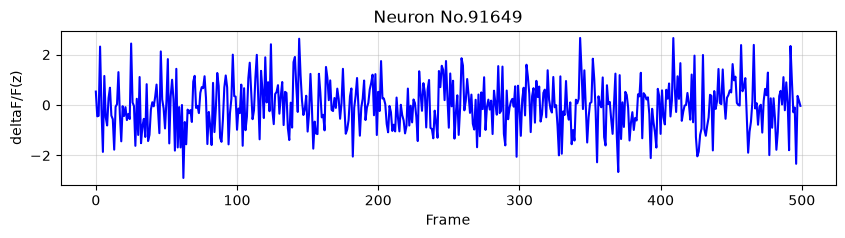

In [7]:
#Visualize a random neuron activity for the first 500 frames
import random
index = random.randint(0, 92538)
plt.figure(figsize=(10,2))
plt.title(f"Neuron No.{index}")
plt.grid(alpha = 0.4)
plt.plot(cell_resp_z[index][1][:500],c = "blue")
plt.xlabel("Frame")
plt.ylabel("deltaF/F(z)")
plt.show()

## Step 2.2: Example Case — Extracting Periodic Neural Activity via Fourier Transformation

In this section, we begin the analysis pipeline by extracting **periodic components** from the neural activity data, focusing on neurons whose activity patterns resemble the **periodic structure of the stimulus**.

The rationale is straightforward: neurons involved in processing the stimulus are expected to exhibit activity patterns that reflect the same periodic timing as the input stimulus.

To identify such neurons, we apply **Fourier transformation** to each neuron’s activity trace, allowing us to quantify key signal properties such as **frequency, wavelength, phase,** and **amplitude**. These features will later serve as classification criteria for identifying **stimulus-locked neurons**.

Before analyzing the entire dataset, we will first demonstrate the procedure on a single example neuron. Specifically, we will perform a Fourier transformation on **Neuron No. 25881** — a representative neuron showing strong periodic activity.

Run the following code block to visualize its activity trace over the first **500 frames**.

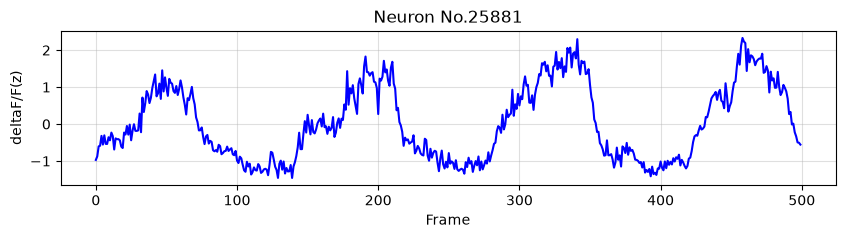

In [8]:
#Visualize neuron activity for the first 500 frames
plt.figure(figsize=(10,2))
plt.title(f"Neuron No.25881")
plt.plot(cell_resp_z[25881][1][:500],c = "blue")
plt.xlabel("Frame")
plt.ylabel("deltaF/F(z)")
plt.grid(alpha=0.4)
plt.show()

As the graph shows, the activity of the selected neuron is **highly periodic**.

Next, we will apply a **Fourier transform** to extract key properties of this periodic component: **frequency (wavelength), amplitude,** and **phase**.

Recall that the Fourier transform decomposes the signal into a sum of sinusoidal components at different frequencies. From these components, we will **select the one whose frequency matches the stimulus** and treat it as the **stimulus-locked component**.

Run the following code cell to perform the Fourier transform and identify the key properties of the stimulus-locked activity.


In [9]:
from demo_functions import check_phase, check_frequency, check_amplitude, check_wavelength

# --- Parameters
stimulus_wavelength = 140
stimulus_frequency = 1 / stimulus_wavelength

# --- Data
activity = cell_resp_z[25881][1]

# --- Compute frequencies once
freqs = check_frequency(activity)
stim_locked_idx = np.where(np.isclose(freqs, stimulus_frequency, rtol=1e-3))[0]

if stim_locked_idx.size == 0:
    print("❌ Stimulus frequency not found in this neuron’s activity.")
else:
    idx = stim_locked_idx[0].item()   # safe scalar extraction

    wavelength = check_wavelength(activity)[idx]
    phase = check_phase(activity)[idx]
    amplitude = check_amplitude(activity)[idx]

    print(f"✅ Frequency match found at index {idx}")
    print(f"Frequency: {freqs[idx]:.6f}")
    print(f"Wavelength: {wavelength}")
    print(f"Phase: {phase}")
    print(f"Amplitude: {amplitude}")


✅ Frequency match found at index 0
Frequency: 0.007143
Wavelength: 140
Phase: 47.12955064424665
Amplitude: 1.2906861305236816


From the output above, we identified the following properties of the **stimulus-locked component** in the neuron's activity data:

- **Frequency:** 0.007143 Hz
- **Wavelength:** 140 frames
- **Phase:** 47.13 frames
- **Amplitude:** 1.291

Using these parameters, we can reconstruct a **simulated signal** that represents the periodic component of the neuron’s response aligned with the stimulus.

Run the following code block to visualize this simulated signal (**red**) overlaid on the raw neural activity (**blue**) for the first **500 frames**.


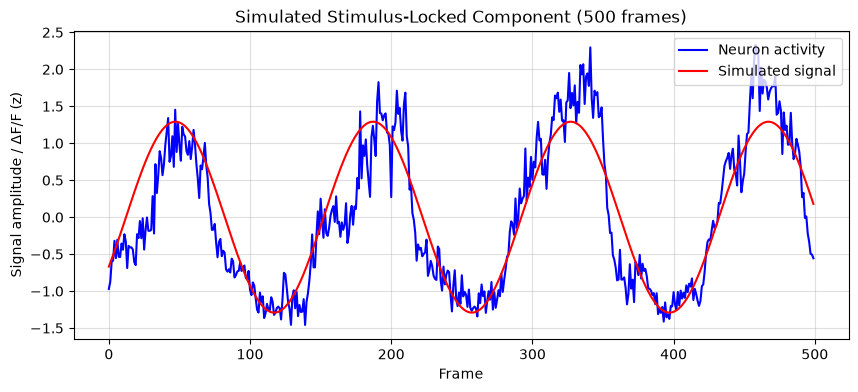

In [10]:
frequency = 0.007143   # Hz (1/140)
wavelength = 140       # frames per cycle
phase = 47.1296        # in frames
amplitude = 1.291
num_frames = 500

# Generate time axis (in frames)
frames = np.arange(num_frames)

# Construct simulated periodic signal
sim_signal = amplitude * np.cos(2 * np.pi * frequency * (frames-phase))

# Plot
plt.figure(figsize=(10, 4))
# Original neuron activity (first 500 frames)
plt.plot(cell_resp_z[25881][1][:500], color='blue', label='Neuron activity')
# Simulated signal
plt.plot(frames, sim_signal, color='red', label='Simulated signal')
plt.title("Simulated Stimulus-Locked Component (500 frames)")
plt.xlabel("Frame")
plt.ylabel("Signal amplitude / ΔF/F (z)")
plt.grid(alpha=0.4)
plt.legend(loc='upper right')
plt.show()

It is important to note that only in rare cases can a neuron's activity be accurately represented by a **single sinusoidal function**.

However, the component that precisely matches the **stimulus frequency** can still serve as a useful approximation of the **stimulus-locked activity** — the portion of the neural signal that reflects the input stimulus.

Not all neurons exhibit such a component in their activity traces. In the next step, we will **filter out neurons** that do not contain a frequency component matching the stimulus periodicity.


## Step 2.3: Identify Stimulus-Locked Neurons from Fourier Results

We now filter the dataset by checking whether each neuron’s activity contains a **periodic component** whose **frequency matches the stimulus**.

Because we target a fixed frequency (here **1/140 Hz**), we also extract the **phase** and **amplitude** **at that frequency** for downstream classification (Step 3).

> **Note:** Due to floating-point precision, we match frequency using a small tolerance (e.g., `np.isclose(..., rtol=1e-3)`), not exact equality.

Run the following code cell to (1) identify neurons with a component at the stimulus frequency and (2) extract the corresponding **phase** and **amplitude**. *This may take several minutes.*


In [11]:
from demo_functions import check_phase, check_frequency, check_amplitude, check_wavelength
import numpy as np
import time

# --- Parameters
stimulus_wavelength = 140
stimulus_frequency = 1 / stimulus_wavelength

# --- Results storage
n_neurons = len(cell_resp_z)
stim_locked_neuronId = []
stim_locked_amplitude = []
stim_locked_phase = []

# --- Progress setup

print(f"Starting Fourier analysis for {n_neurons} neurons...")
print("This may take several minutes depending on dataset size.\n")

# --- Main loop
for idx, (neuron_id, activity) in enumerate(cell_resp_z):

    # Compute frequency spectrum
    freqs = check_frequency(activity)

    # Find if stimulus frequency exists in spectrum
    stim_locked_idx = np.where(np.isclose(freqs, stimulus_frequency, rtol=1e-3))[0]

    # If found → record neuron info
    if stim_locked_idx.size > 0:
        k = stim_locked_idx[0].item()
        stim_locked_neuronId.append(neuron_id)
        stim_locked_amplitude.append(check_amplitude(activity)[k])
        stim_locked_phase.append(check_phase(activity)[k])

    # Manual progress print every 1000 neurons
    if (idx + 1) % 1000 == 0 or (idx + 1) == n_neurons:
        pct = (idx + 1) / n_neurons * 100
        print(f"Processed {idx + 1}/{n_neurons} neurons ({pct:.1f}%)")

print(f"\n✅ Analysis complete! Found {len(stim_locked_neuronId)} stimulus-locked neurons. ({100*len(stim_locked_neuronId)/len(cell_resp_z):.1f}%)")
stim_locked_neuron = np.column_stack((
    np.array(stim_locked_neuronId, dtype=int),
    np.array(stim_locked_amplitude, dtype=float),
    np.array(stim_locked_phase, dtype=float)
))


Starting Fourier analysis for 92538 neurons...
This may take several minutes depending on dataset size.



Processed 1000/92538 neurons (1.1%)


Processed 2000/92538 neurons (2.2%)


Processed 3000/92538 neurons (3.2%)


Processed 4000/92538 neurons (4.3%)


...

Processed 88000/92538 neurons (95.1%)


Processed 89000/92538 neurons (96.2%)


Processed 90000/92538 neurons (97.3%)


Processed 91000/92538 neurons (98.3%)


Processed 92000/92538 neurons (99.4%)
Processed 92538/92538 neurons (100.0%)

✅ Analysis complete! Found 66789 stimulus-locked neurons. (72.2%)


After filtering, **66,789 neurons** were identified as having a periodic component that matches the **stimulus frequency**.

This step alone provides limited insight into the underlying computation: the set is still too large (over 70% of the original dataset) to interpret meaningfully.

To highlight neurons most likely involved in **stimulus processing**, we will apply additional criteria in the next step—e.g., **phase alignment** with stimulus windows (Frames **30–70** or **100–140**) and **amplitude** thresholds at the stimulus frequency—to prioritize the most strongly stimulus-locked neurons.


## Step 3: Selecting Stimulus-Locked Neurons Based on Phase and Amplitude
*Corresponds to Figure 3 in the manuscript.*

In this step, we further refine the group of **stimulus-locked neurons** identified earlier by examining two key properties of their periodic components: **phase** and **amplitude**.

Because we are interested in neurons that are **strongly correlated with the stimulus signal**, two conditions must be met:
1. The neuron must exhibit **strong periodic activity** (high amplitude).
2. The neuron’s activity must be **synchronized in time** with the stimulus presentation (phase alignment).

These two pieces of information are captured in the neuron's **amplitude** and **phase** values extracted from its Fourier component at the stimulus frequency.

To help us design a selection criterion for identifying the most significant group of neurons in the Amplitude–Phase plot,
we first examine how neurons are distributed along each dimension individually. Thus, we first visualize the overall distribution of neurons in the **Amplitude–Phase domain** to observe how these properties vary across the population.

Run the following code cell to plot all stimulus-locked neurons in the amplitude–phase plane.


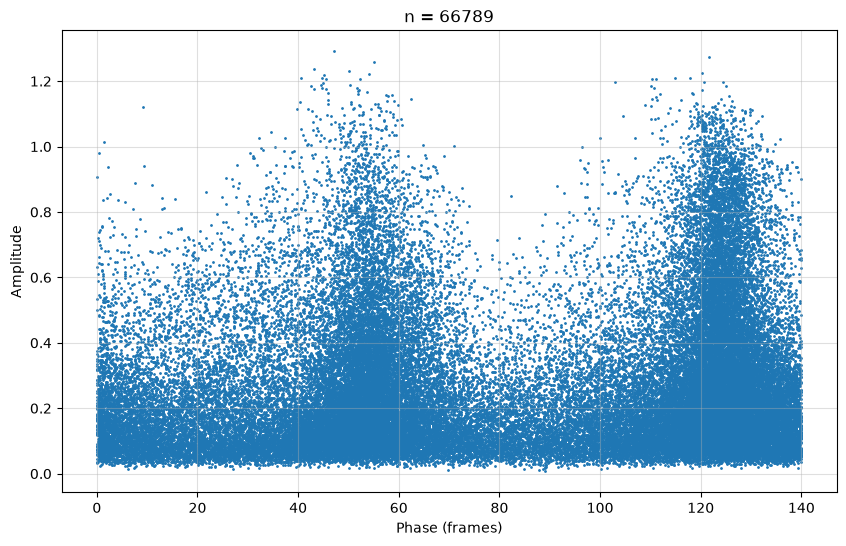

In [12]:
#plot
plt.figure(figsize = (10,6))
plt.grid(alpha=0.4)
plt.scatter(stim_locked_phase,stim_locked_amplitude,s = 1)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'n = {len(stim_locked_neuron)}')
plt.show()

### Step 3.1: Selection Criterion 1 — Amplitude Threshold

The first selection criterion is an **amplitude threshold**.

To understand the distribution of amplitudes, we visualize the **frequency distribution** (histogram) of stimulus-locked neurons’ amplitudes. This reveals typical ranges, density peaks, and potential cutoff points for defining **high-amplitude** populations.

Run the following code cells to visualize the distributions of amplitude among all stimulus-locked neurons.

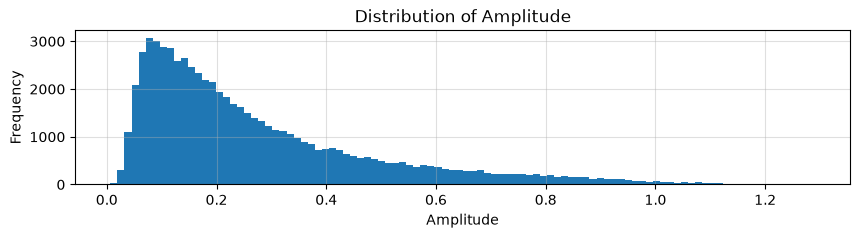

In [13]:
plt.figure(figsize = (10,2))
plt.title("Distribution of Amplitude")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.hist(stim_locked_amplitude,bins = 100)
plt.grid(alpha=0.4)
plt.show()


The amplitude distribution exhibits a **long tail** toward higher amplitudes. Because we are interested in neurons that exhibit the **strongest activity**, we retain only the top *k%* of neurons with the highest amplitudes.

Here, **k** serves as an adjustable cutoff that balances **significance** and **completeness** in the analysis:

- Increasing *k* (a stricter cutoff) prioritizes **significance** by excluding neurons with weak activity, but may reduce the completeness of the identified population.
- Decreasing *k* (a looser cutoff) increases **completeness** by including more neurons, but risks incorporating weakly stimulus-related signals.

In this analysis, we set **k = 10**, selecting the **top 10% of neurons** ranked by amplitude. This threshold matches the selection criterion used in the accompanying manuscript.

Run the following code cell to **apply the amplitude cutoff** and visualize the resulting subset of neurons in the **Amplitude–Phase plane**.

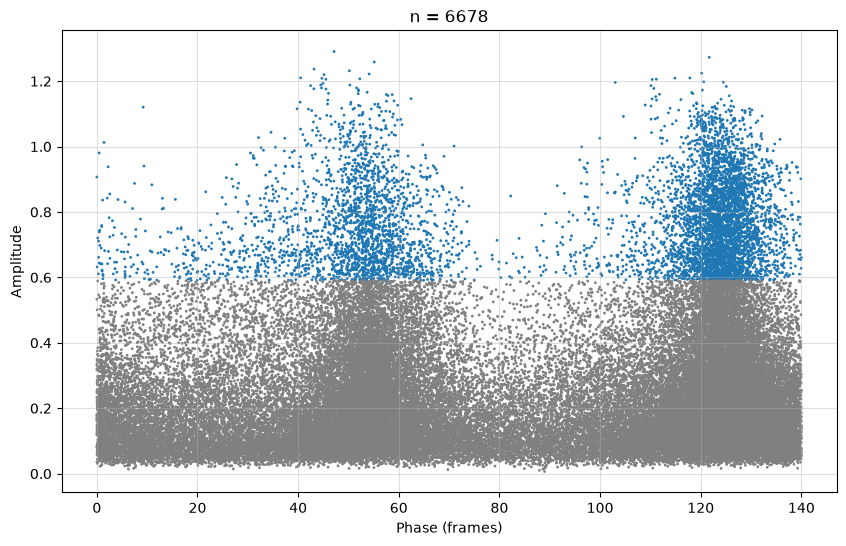

In [14]:
# Step 1 — Parameter
k = 10 #cutoff
cutoff = k/100

# Step 2 — Sort by amplitude (descending)
stim_sorted = stim_locked_neuron[np.argsort(stim_locked_neuron[:, 1])[::-1]]

# Step 3 — Determine how many are in the top 10%
n_total = len(stim_sorted)
n_top = int(n_total * cutoff)  # 10%

# Step 4 — Get the IDs of top 10% neurons
top_neurons = stim_sorted[:n_top, 0].astype(int)

# Step 5 — Create a binary selection vector (1 if selected, else 0)
selection_mask = [1] * n_top + [0] * (n_total-n_top)

# Step 6 — Create auxiliary variables for visualization
colors = ['tab:blue' if x == 1 else 'grey' for x in selection_mask]
sorted_phase = stim_sorted[:, 2]
sorted_amplitude = stim_sorted[:, 1]

# Plot
plt.figure(figsize = (10,6))
plt.grid(alpha=0.4)
plt.scatter(sorted_phase,sorted_amplitude,s = 1, color = colors)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'n = {n_top}')
plt.show()


The plot above shows the result of applying a 10% amplitude cutoff.

Neurons colored in **blue** represent those retained after the cutoff, while **gray** neurons were excluded. Conceptually, the amplitude threshold acts as a **horizontal divider**, selecting only neurons with strong periodic activity.

### Step 3.2: Selection Criterion 2 — Phase Constraint

Next, we further refine this subset by applying a **phase constraint**.

The **phase** represents the temporal offset of a neuron’s activity cycle — that is, the point in time within each periodic cycle at which the neuron’s activity reaches its peak. Intuitively, if we approximate a neuron’s activity using a sinusoidal function, the phase corresponds to the **time position of the activity maximum** within each stimulus cycle.

Before applying any cutoff, it is helpful to first examine the **distribution of phase values** across all stimulus-locked neurons.  This allows us to observe whether neurons tend to cluster around specific time windows that correspond to the stimulus presentation periods, and how strongly the stimulus timing influences the overall phase distribution.

Run the following code cell to visualize the frequency distribution of phase among all stimulus-locked neurons.


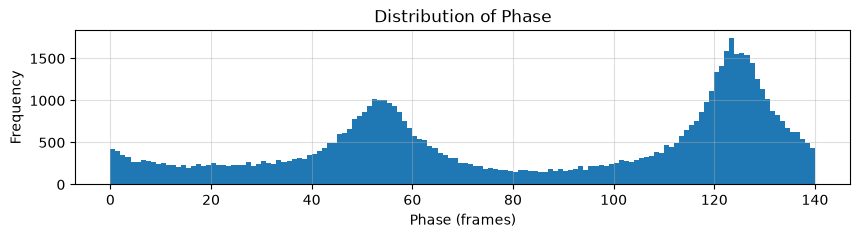

In [15]:
plt.figure(figsize = (10,2))
plt.title("Distribution of Phase")
plt.xlabel("Phase (frames)")
plt.ylabel("Frequency")
plt.hist(stim_locked_phase,bins = 140)
plt.grid(alpha=0.4)
plt.show()

As shown in the histogram above, the neurons form a **bimodal distribution**, with two prominent peaks centered around **Phase ≈ 50** and **Phase ≈ 120**. These two time points correspond closely to the midpoints of the right- and left-sided stimulus presentation windows, respectively.

This observation suggests that a large proportion of neurons exhibit activity synchronized with the alternating stimulus pattern. To isolate these neurons, we apply a **phase constraint** based on the known timing of the stimulus presentation.

Unlike the amplitude threshold, which is empirically chosen, the phase constraint is **directly defined** by the temporal structure of the stimulus itself.

Specifically, we retain only the neurons whose phase values fall within the two stimulus presentation windows:

- **Right-sided stimulus:** Frames **30–70**
- **Left-sided stimulus:** Frames **100–140**

Run the following code cell to apply the phase constraint and visualize the resulting neurons in the **Amplitude–Phase plane**.


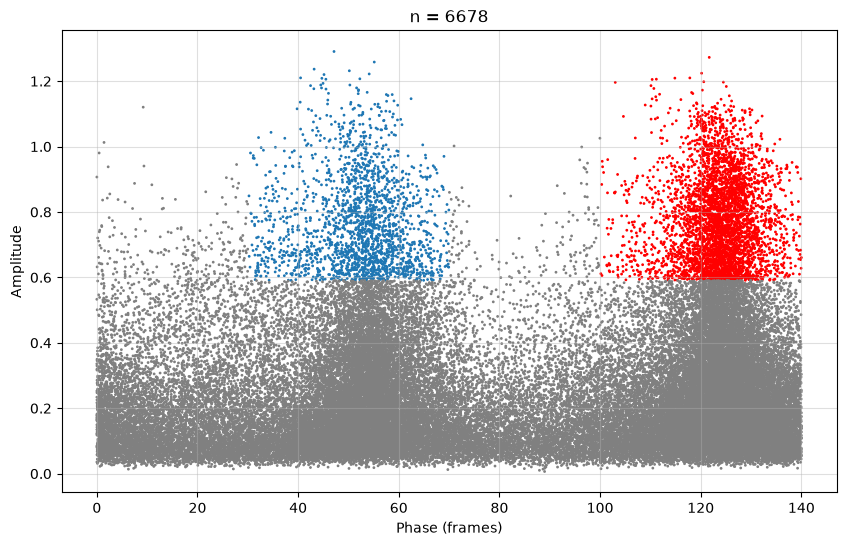

In [16]:
# Parameters
phase = stim_sorted[:, 2]
n_top = int(n_total * cutoff)
n_total = len(stim_sorted)

# Define windows (inclusive)
win_right = (30, 70)
win_left = (100, 140)

# Create selection mask
phase_mask = []
for i in range(n_top):
    if phase[i] >= win_right[0] and phase[i] <= win_right[1]:
        phase_mask.append(1)
    elif phase[i] >= win_left[0] and phase[i] <= win_left[1]:
        phase_mask.append(2)
    else:
        phase_mask.append(0)

phase_mask += (n_total-n_top) * [0]

# Create auxiliary variables for visualization
colors = ['tab:blue' if x == 1 else 'red' if x == 2 else 'grey' for x in phase_mask]

# Plot
plt.figure(figsize = (10,6))
plt.grid(alpha=0.4)
plt.scatter(sorted_phase,sorted_amplitude,s = 1, color = colors)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'n = {n_top}')
plt.show()

Visually, the **phase constraint** acts as a **vertical divider** on the Amplitude–Phase plane.

After applying this constraint, we have successfully identified and labeled the significant neurons, assigning each according to its corresponding **stimulus presentation window**. This assignment naturally associates each neuron with the **stimulus presented on either the left or right side**.

In the plot above, neurons colored in **blue** are associated with the **right-sided stimulus**, while those in **red** correspond to the **left-sided stimulus**. Together, these neurons represent the **stimulus-locked population** — a subset whose activity patterns are both **strong in amplitude** and **temporally aligned in phase** with the timing of the visual stimulation.



## Step 4: Spatial Mapping of Stimulus-Locked Neurons
*Corresponds to Figure 4-7 in the manuscript.*

In this section, we transition from analyzing the temporal and spectral properties of neuron activity to examining their **spatial organization** within the zebrafish brain.

The goal is to **visualize the anatomical distribution** of the stimulus-locked neurons identified in Step 3, and to explore whether neurons associated with the **left- or right-sided stimuli** occupy distinct or symmetric regions.

By mapping the neurons in anatomical space, we can gain insights into **how periodic visual stimuli are represented across brain structures**.
The spatial coordinates of each neuron are obtained from the imaging dataset (`absIX`), which provides the 3-D location of every neuron in the field of view.

Run the following code block to load the normalized zebrafish brain outline data



In [17]:
# Read all three outlines
outline_xy = pd.read_excel(DATA_DIR / "outline_xy.xlsx", header=None).to_numpy()
outline_yz = pd.read_excel(DATA_DIR / "outline_yz.xlsx", header=None).to_numpy()
outline_zx = pd.read_excel(DATA_DIR / "outline_zx.xlsx", header=None).to_numpy()

# get all coordinates where value is 1
xy_lines = np.argwhere(outline_xy)
yz_lines = np.argwhere(outline_yz)
zx_lines = np.argwhere(outline_zx)

### Step 4.1: Spatial visualization of stimulus-locked neurons (combined map)
*Corresponds to Figure 4 in the manuscript (single-fish case, n = 1).*

We now visualize the spatial distribution of all stimulus-locked neurons. Neurons associated with **right-sided stimulation** are shown in blue, and those associated with **left-sided stimulation** in red. Both groups are rendered together in the same anatomical projection.

**Run the next four code cells to:**
1) Read and prepare coordinates for neurons and brain outlines.
2) Render **Top (XY)**, **Side (YZ)**, and **Front (ZX)** projections in one figure.


In [18]:
# Assign neurons by previous filters
phase_mask = np.array(phase_mask)

# Select neuron indices for right and left stimuli
right_stimulus_neuron = stim_sorted[phase_mask == 1][:, 0].astype(int)
left_stimulus_neuron  = stim_sorted[phase_mask == 2][:, 0].astype(int)

# Extract coordinates (assuming coordinate[i][1] = [x, y, z])
def extract_xyz(indices, coordinate):
    coords = np.array([coordinate[i][1] for i in indices])
    return coords[:, 0], coords[:, 1], coords[:, 2]

left_stimulus_x, left_stimulus_y, left_stimulus_z = extract_xyz(left_stimulus_neuron, coordinate)
right_stimulus_x, right_stimulus_y, right_stimulus_z = extract_xyz(right_stimulus_neuron, coordinate)

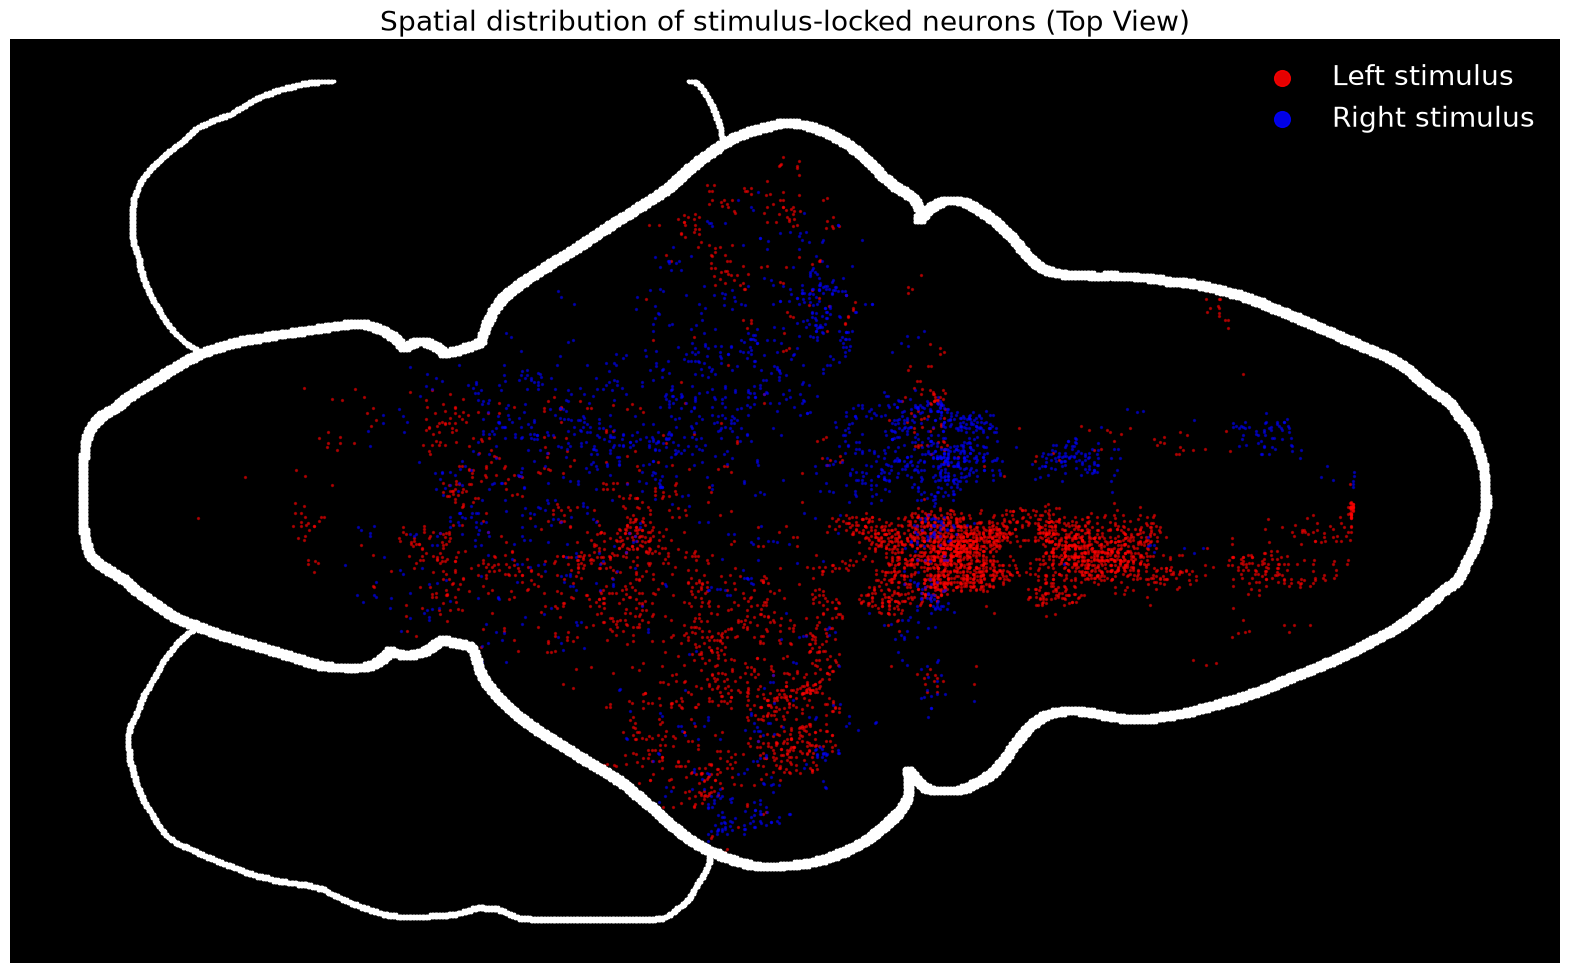

In [19]:
# Top View
plt.figure(figsize=(20, 12))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(left_stimulus_x, left_stimulus_y, s=2, alpha=0.5, c='red',  label='Left stimulus')
right_plot = plt.scatter(right_stimulus_x, right_stimulus_y, s=2, alpha=0.5, c='blue', label='Right stimulus')

# Outline
plt.scatter(xy_lines[:, 0], xy_lines[:, 1], s=3, c="white", alpha=1)

# Legend
legend = plt.legend(
    handles=[left_plot, right_plot],
    loc='upper right',
    frameon=False,
    fontsize=20,
    labelcolor='white',
    scatterpoints=1,
    markerscale=8
)
for lh in legend.legend_handles:
    lh.set_alpha(0.9)

plt.title("Spatial distribution of stimulus-locked neurons (Top View)", fontsize=20)
plt.show()


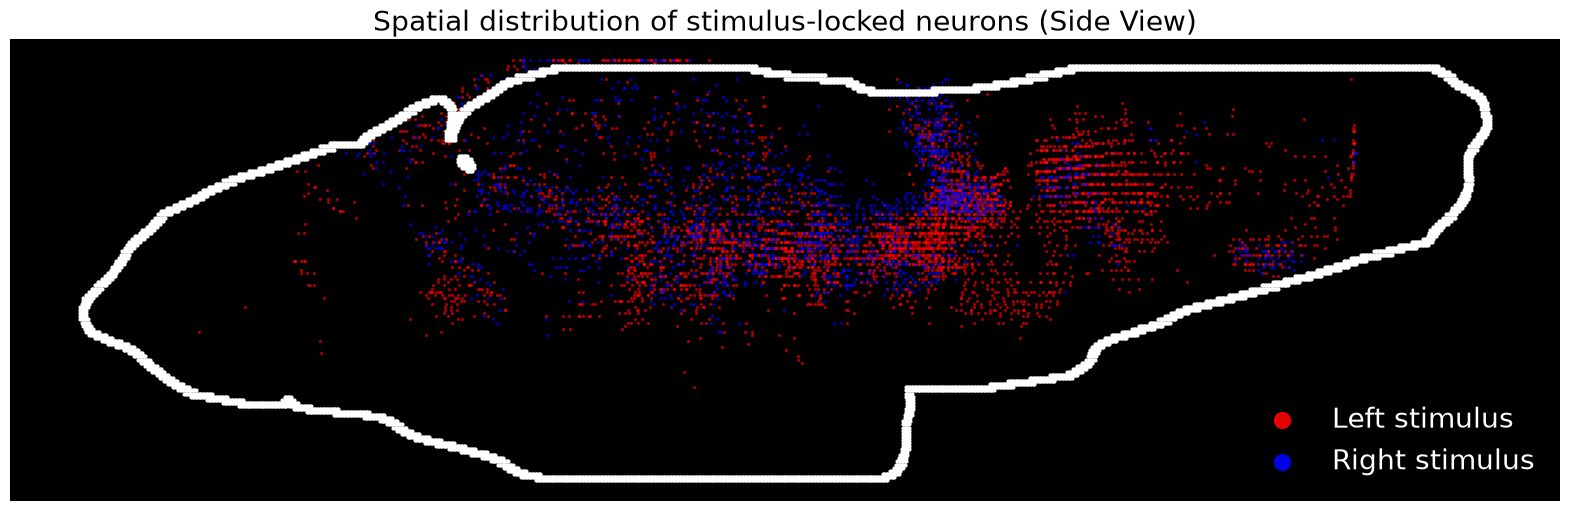

In [20]:
# Side View
plt.figure(figsize=(20, 6))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(left_stimulus_x, left_stimulus_z, s=2, alpha=0.5, c='red',  label='Left stimulus')
right_plot = plt.scatter(right_stimulus_x, right_stimulus_z, s=2, alpha=0.5, c='blue', label='Right stimulus')

# Outline
plt.scatter(yz_lines[:, 0], yz_lines[:, 1], s=4, c="white", alpha=1)

# Legend with larger color markers
legend = plt.legend(
    handles=[left_plot, right_plot],
    loc='lower right',
    frameon=False,
    fontsize=20,
    labelcolor='white',
    scatterpoints=1,
    markerscale=8
)
for lh in legend.legend_handles:
    lh.set_alpha(0.9)

plt.title("Spatial distribution of stimulus-locked neurons (Side View)", fontsize=20)
plt.show()

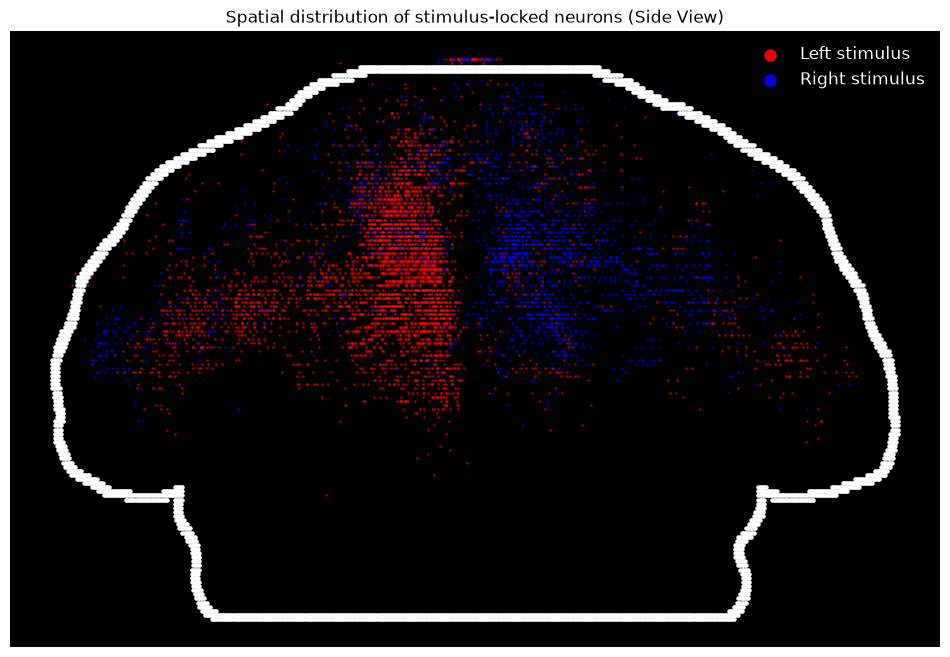

In [21]:
# Front View
plt.figure(figsize=(12, 8))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(left_stimulus_y, left_stimulus_z, s=1, alpha=0.5, c='red',  label='Left stimulus')
right_plot = plt.scatter(right_stimulus_y, right_stimulus_z, s=1, alpha=0.5, c='blue', label='Right stimulus')

# Outline
plt.scatter(zx_lines[:, 1], zx_lines[:, 0], s=5, c="white", alpha=1)

# Legend with larger color markers
legend = plt.legend(
    handles=[left_plot, right_plot],
    loc='upper right',
    frameon=False,
    fontsize=12,
    labelcolor='white',
    scatterpoints=1,
    markerscale=8
)
for lh in legend.legend_handles:
    lh.set_alpha(0.9)

plt.title("Spatial distribution of stimulus-locked neurons (Side View)", fontsize=12)
plt.show()

These plots visualize the spatial distribution of neurons responding to left- and right-sided phototaxis stimulation. The results reveal a pronounced **laterality** in neuronal activity patterns, with distinct activation domains across several brain regions, notably the **midbrain** and **hindbrain**.

Further analysis and interpretation of these spatial patterns are presented in the manuscript (Figure 4).

### Step 4.2: Phase-based Spatial Mapping of Neuronal Activation
*Corresponds to Figure 5 in the manuscript.*

Fourier analysis additionally provides **phase information**, which encodes the relative timing of each neuron's peak response. To investigate activation sequences across neural populations during phototaxis, we aligned each neuron’s phase to its corresponding stimulus onset, creating a **normalized phase dimension**.

While this normalized phase does not represent absolute response latency—since the sinusoidal Fourier approximation may not fully capture exact neuronal dynamics—it effectively reveals **relative activation sequences** between neuronal groups.

Neurons were then mapped according to their anatomical coordinates and **color-coded by their phase values**, enabling spatial–temporal visualization of activation patterns across brain regions.

**Run the next four code cells to:**
1) Read and prepare color spectrum for neurons based on their phase. And visualize the phase spectrum
2) Render **Top (XY)**, **Side (YZ)**, and **Front (ZX)** projections in one figure.

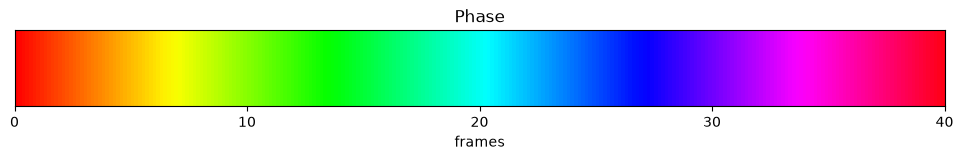

In [22]:
# Read the phase of the selected neurons
right_stimulus_phase = stim_sorted[phase_mask == 1][:, 2].astype(float) - 30 #onset of right stimulus
left_stimulus_phase  = stim_sorted[phase_mask == 2][:, 2].astype(float) - 100 #onset of left stimulus

# Create a color spectrum
cmap = plt.get_cmap('hsv')
norm = plt.Normalize(vmin=0, vmax=39)  # Normalize to [100, 140]
left_phase_color = cmap(norm(left_stimulus_phase))
right_phase_color = cmap(norm(right_stimulus_phase))

#Phase spectrum
fig, ax = plt.subplots(figsize=(12, 2))  # Width x Height (in inches)
fig.subplots_adjust(bottom=0.5)  # Adjust position

# Create a gradient from 0 to 1 (viridis is the default colormap)
gradient = np.linspace(0, 1, 256).reshape(1, -1)
img = ax.imshow(gradient, aspect='auto', cmap='hsv', extent=[0, 40, 0, 1])

# Customize the colorbar
ax.set_yticks([])  # Hide y-axis
ax.set_xlabel('frames')  # Add label
ax.set_xticks([0, 10, 20, 30, 40])  # Set custom ticks
plt.title('Phase')

plt.show()

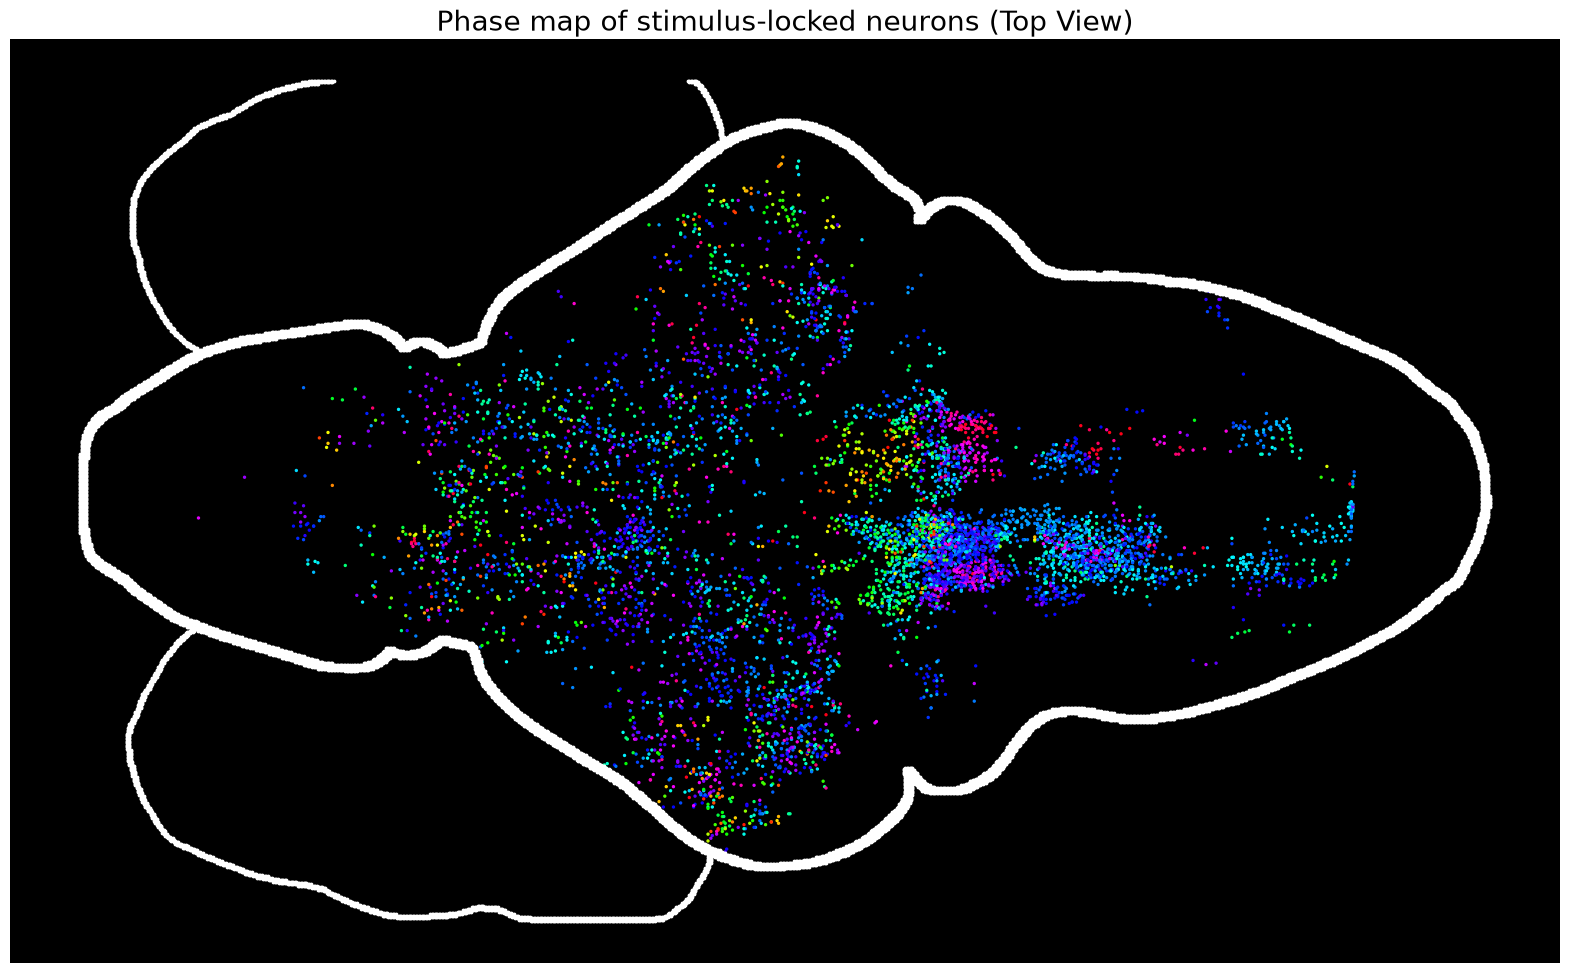

In [23]:
# Top View
plt.figure(figsize=(20, 12))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(left_stimulus_x, left_stimulus_y, s=2, alpha=1, c=left_phase_color,  label='Left stimulus')
right_plot = plt.scatter(right_stimulus_x, right_stimulus_y, s=2, alpha=1, c=right_phase_color, label='Right stimulus')

# Outline
plt.scatter(xy_lines[:, 0], xy_lines[:, 1], s=3, c="white", alpha=1)

plt.title("Phase map of stimulus-locked neurons (Top View)", fontsize=20)
plt.show()

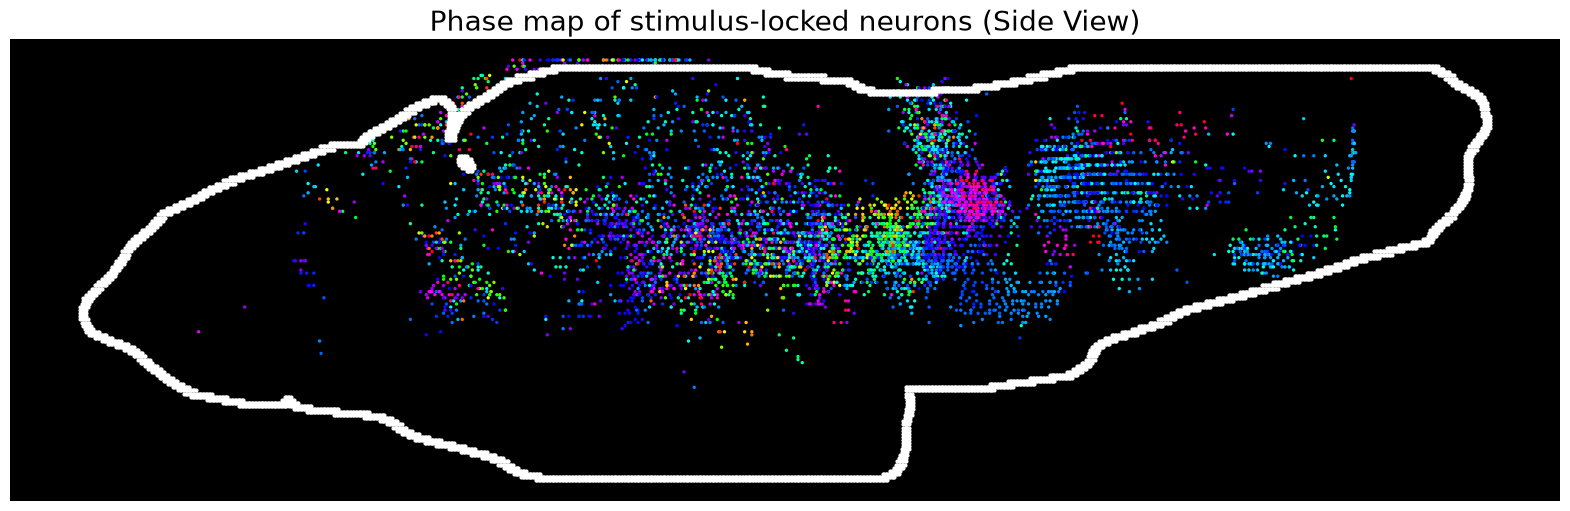

In [24]:
# Side View
plt.figure(figsize=(20, 6))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(left_stimulus_x, left_stimulus_z, s=2, alpha=1, c=left_phase_color,  label='Left stimulus')
right_plot = plt.scatter(right_stimulus_x, right_stimulus_z, s=2, alpha=1, c=right_phase_color, label='Right stimulus')

# Outline
plt.scatter(yz_lines[:, 0], yz_lines[:, 1], s=4, c="white", alpha=1)

plt.title("Phase map of stimulus-locked neurons (Side View)", fontsize=20)
plt.show()

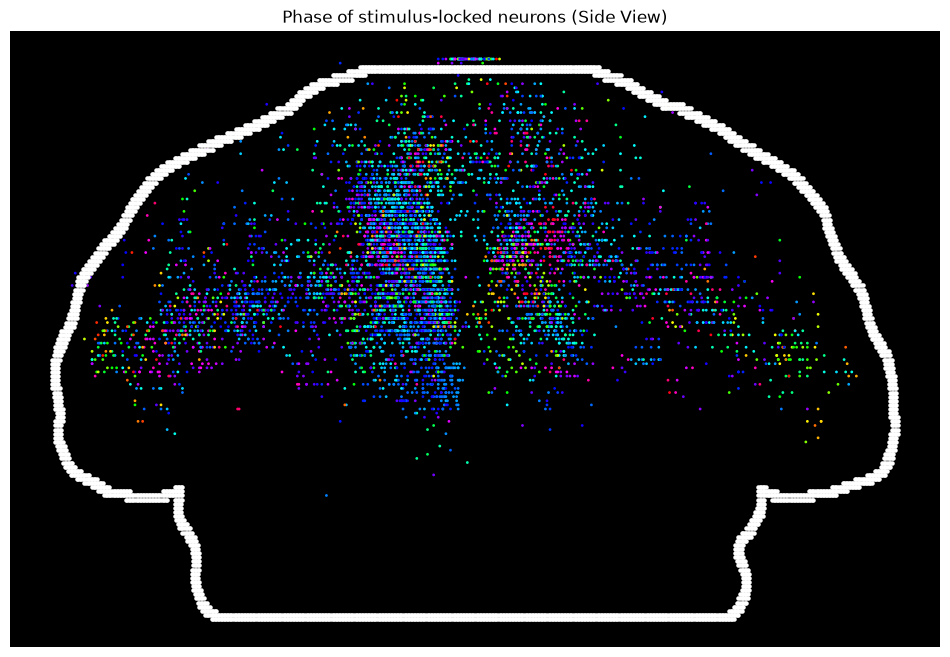

In [25]:
# Front View
plt.figure(figsize=(12, 8))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(left_stimulus_y, left_stimulus_z, s=1, alpha=1, c=left_phase_color,  label='Left stimulus')
right_plot = plt.scatter(right_stimulus_y, right_stimulus_z, s=1, alpha=1, c=right_phase_color, label='Right stimulus')

# Outline
plt.scatter(zx_lines[:, 1], zx_lines[:, 0], s=5, c="white", alpha=1)

plt.title("Phase of stimulus-locked neurons (Side View)", fontsize=12)
plt.show()

In these figures, each neuron is color-coded according to its **phase normalized to the onset of the associated stimulus**. For example, a neuron with a phase of 120 (associated with a left-sided stimulus beginning at frame 100) has a normalized phase value of 20. This color-coded scatter plot thus serves as a **proxy for the temporal structure** of neuronal activation.

However, because of the high density and spatial overlap of neurons with different phase values, these plots are **not fully informative** about the sequential order of neuronal activation across brain regions. In the next section, we will group neurons into **discrete temporal windows**, enabling a clearer visualization of the **temporal sequence of activation** during phototactic stimulation.


### Step 4.3: Temporal Sequencing and Laterality of Neuron Response
*Corresponds to Figure 6-7 in the manuscript.*

To characterize the **temporal sequence** of neural activation during phototactic stimulation, responsive neurons were categorized into **four sequential phase groups**, each representing one-quarter (10 frames) of the stimulus cycle.

This segmentation enables visualization of how distinct neuronal populations become active over time relative to the periodic stimulus, revealing the **spatiotemporal progression** of neural activity across brain regions.

Run the following cells to implement the **phase-group assignment** and **visualize sequential activation patterns** throughout the brain in top view figures.



In [26]:
# Define windows
phase_window = {'p1': (0,10), 'p2': (10,20), 'p3': (20,30), 'p4': (30,40)}

# Helper function
def build_phase_bins(phases, neuron_ids, colors, phase_window):
    """
    Assign neurons to phase windows.
    - window 1 uses [low, high]
    - subsequent windows use (low, high]
    """
    phases = np.asarray(phases, dtype=float)
    neuron_ids = np.asarray(neuron_ids)
    if colors is not None:
        colors = np.asarray(colors)

    phase_dict = {k: [] for k in phase_window.keys()}
    color_dict = {k: [] for k in phase_window.keys()}

    # Loop through each neuron
    for i in range(len(phases)):
        p = phases[i]
        nid = neuron_ids[i]
        col = colors[i] if colors is not None else None

        # Iterate through the phase window dictionary
        for j, (key, (low, high)) in enumerate(phase_window.items()):
            if j == 0:
                in_bin = (p >= low) and (p <= high)  # [low, high]
            else:
                in_bin = (p > low) and (p <= high)   # (low, high]

            if in_bin:
                phase_dict[key].append(nid)
                if col is not None:
                    color_dict[key].append(col)
                break  # stop checking once assigned

    return phase_dict, color_dict


# LEFT side
left_phase, left_color = build_phase_bins(
    phases      = left_stimulus_phase,
    neuron_ids  = left_stimulus_neuron,
    colors      = left_phase_color,
    phase_window= phase_window
)

# RIGHT side
right_phase, right_color = build_phase_bins(
    phases      = right_stimulus_phase,
    neuron_ids  = right_stimulus_neuron,
    colors      = right_phase_color,
    phase_window= phase_window
)

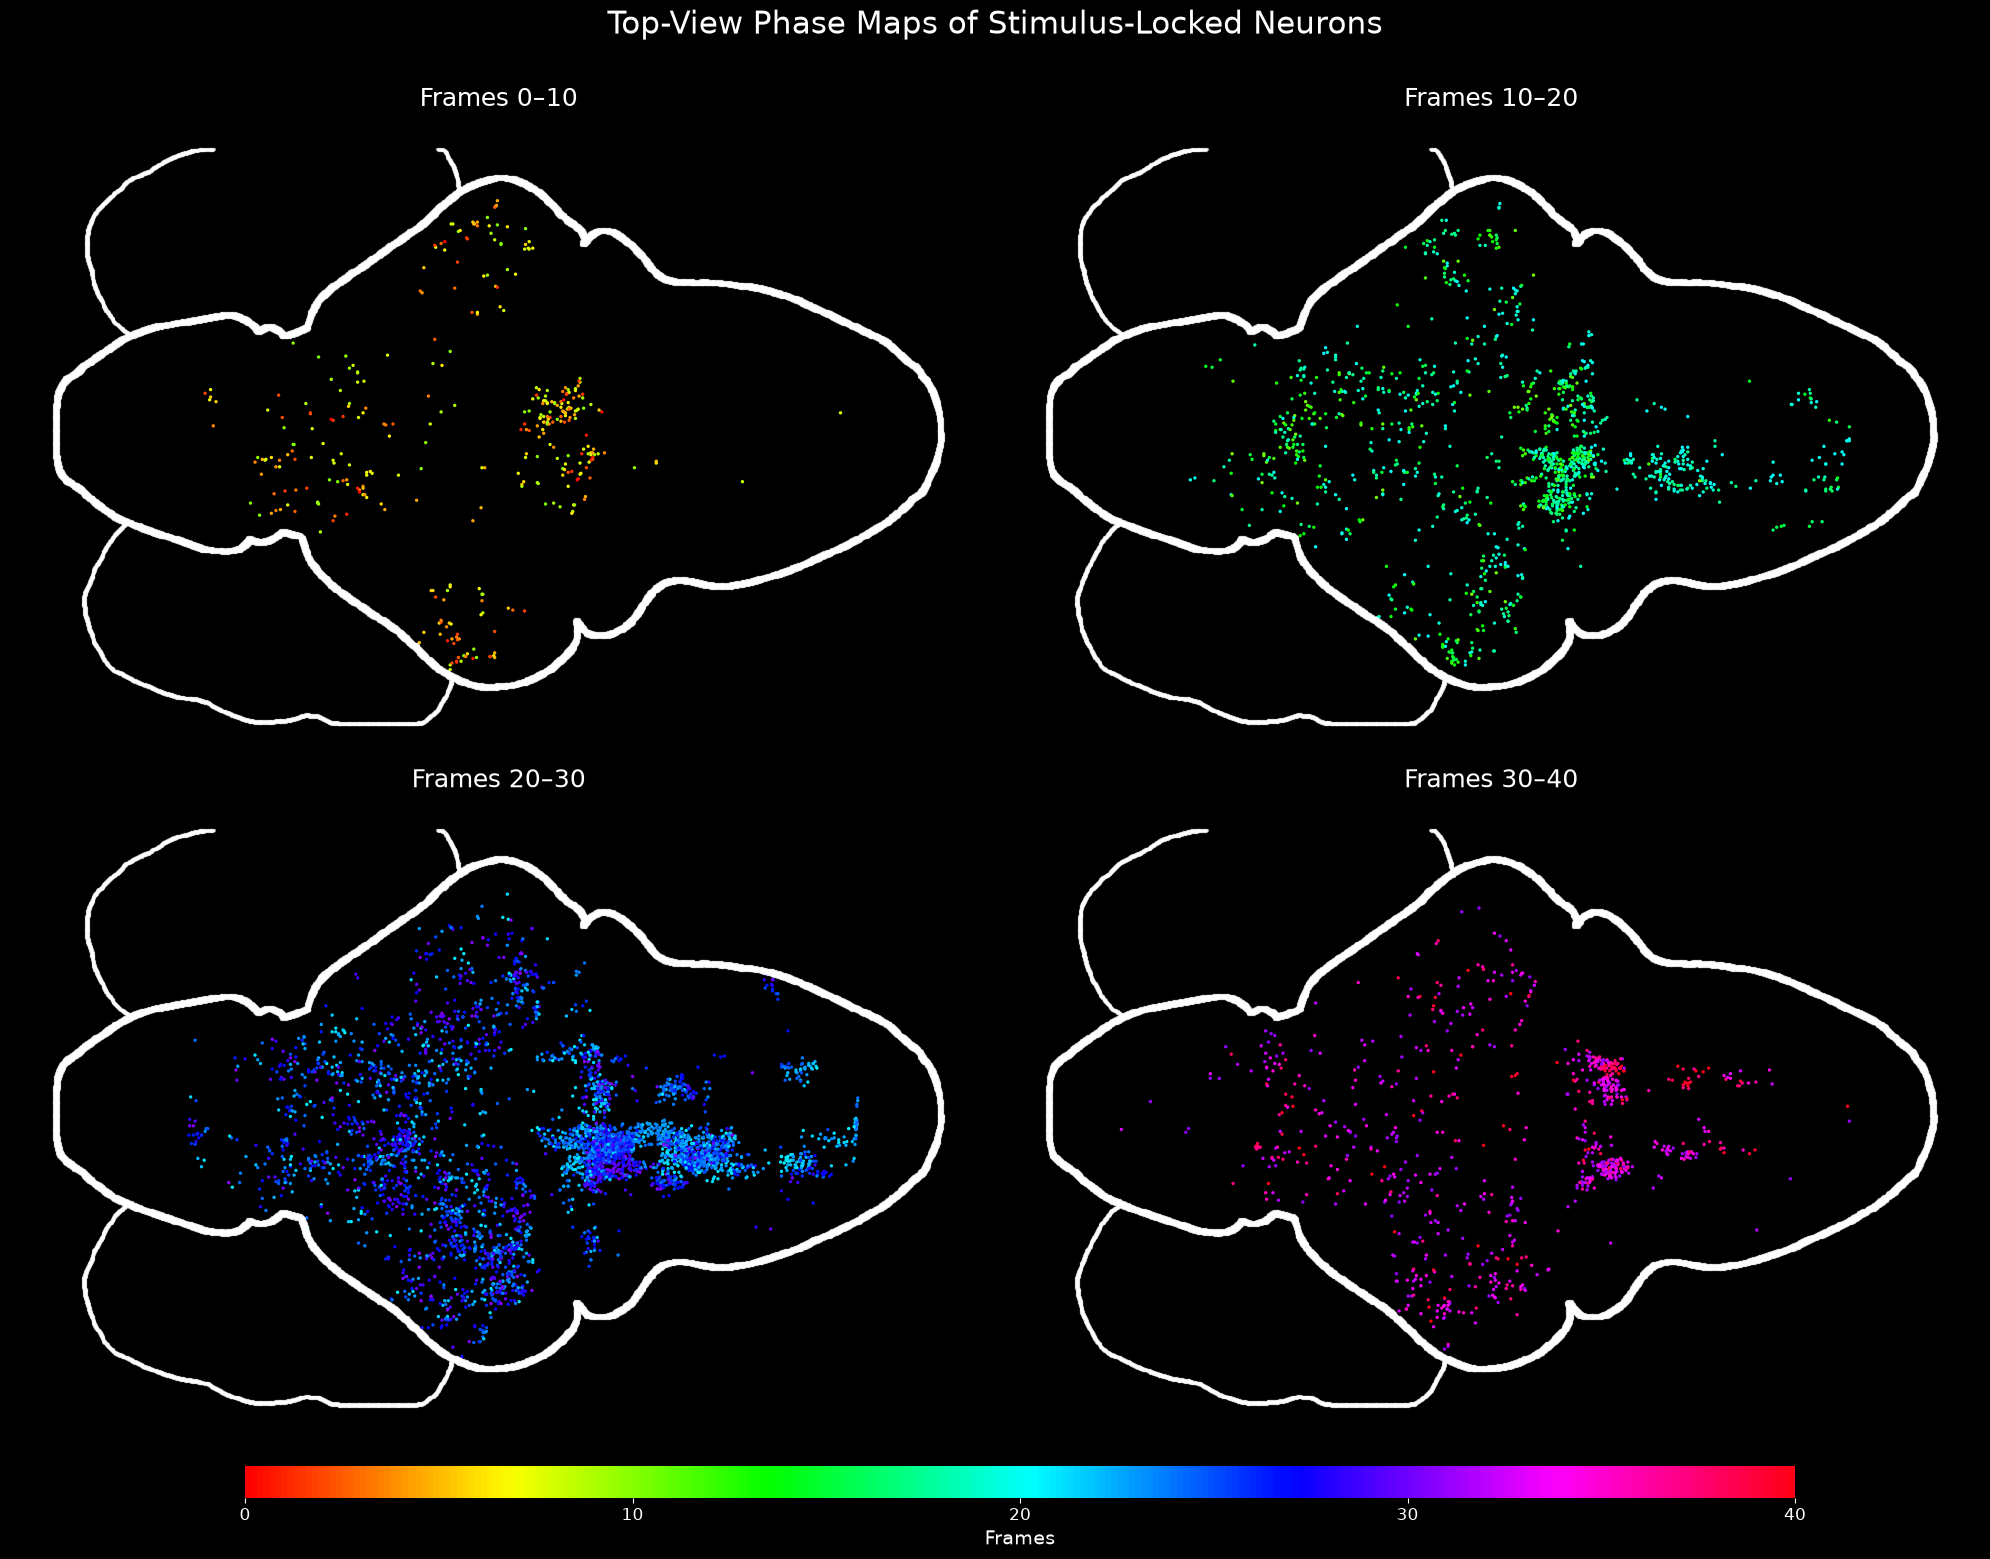

In [27]:
# Plotting
def ordered_phase_subplot(left_phase, right_phase, left_color, right_color, phase_window, coordinate, xy_lines):
    """
    Draws 2×2 subplots showing phase-specific neuron activation maps,
    with a phase color spectrum added at the bottom.
    """
    # --- Set up figure ---
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    fig.patch.set_facecolor('black')  # make entire figure background black

    # ---- 2×2 panels ----
    for idx, key in enumerate(phase_window.keys()):
        ax = axes[idx]
        low, high = phase_window[key]

        # Extract neuron coordinates for each side
        left_idx = left_phase[key]
        right_idx = right_phase[key]

        left_x  = [coordinate[i][1][0] for i in left_idx]
        left_y  = [coordinate[i][1][1] for i in left_idx]
        right_x = [coordinate[i][1][0] for i in right_idx]
        right_y = [coordinate[i][1][1] for i in right_idx]

        # --- Styling ---
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_facecolor('black')

        # --- Outline and neurons ---
        ax.scatter(left_x,  left_y,  s=2, alpha=1, c=left_color[key])
        ax.scatter(right_x, right_y, s=2, alpha=1, c=right_color[key])
        ax.scatter(xy_lines[:, 0], xy_lines[:, 1], s=2, c="white", alpha=0.5)

        # --- Titles ---
        ax.set_title(f"Frames {low}–{high}", fontsize=18, pad=10, color='white')

    # --- Global title & layout ---
    fig.suptitle("Top-View Phase Maps of Stimulus-Locked Neurons",
                 fontsize=22, y=0.95, color='white')
    plt.tight_layout(rect=[0, 0.05, 1, 0.94])

    # ---- Phase spectrum (bottom, thin bar) ----
    ax_spec = fig.add_axes([0.125, 0.02, 0.775, 0.02])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax_spec.imshow(gradient, aspect='auto', cmap='hsv', extent=[0, 40, 0, 1])
    ax_spec.set_yticks([])
    ax_spec.set_xticks([0, 10, 20, 30, 40])
    ax_spec.set_xlabel("Frames", fontsize=14, color='white')
    ax_spec.tick_params(axis='x', colors='white')  # make x ticks white ✅
    ax_spec.set_xticklabels([0, 10, 20, 30, 40], fontsize=12, color='white')  # explicit tick labels ✅
    for spine in ax_spec.spines.values():
        spine.set_visible(False)
    ax_spec.set_facecolor('black')

    plt.show()

ordered_phase_subplot(left_phase, right_phase, left_color, right_color, phase_window, coordinate, xy_lines)


The generated figure reveals a **wide-spread temporal pattern** of neuronal activation across multiple brain regions. At the chosen phase partition, we can distinguish **activation cohorts** at different **stages** of stimulus presentation.

To specifically examine the **laterality encoding** of phototaxis, we next **restrict the analysis to neurons associated with left-sided stimulation**.

Run the following cells to visualize the **phase map for left-stimulus–responsive neurons**.

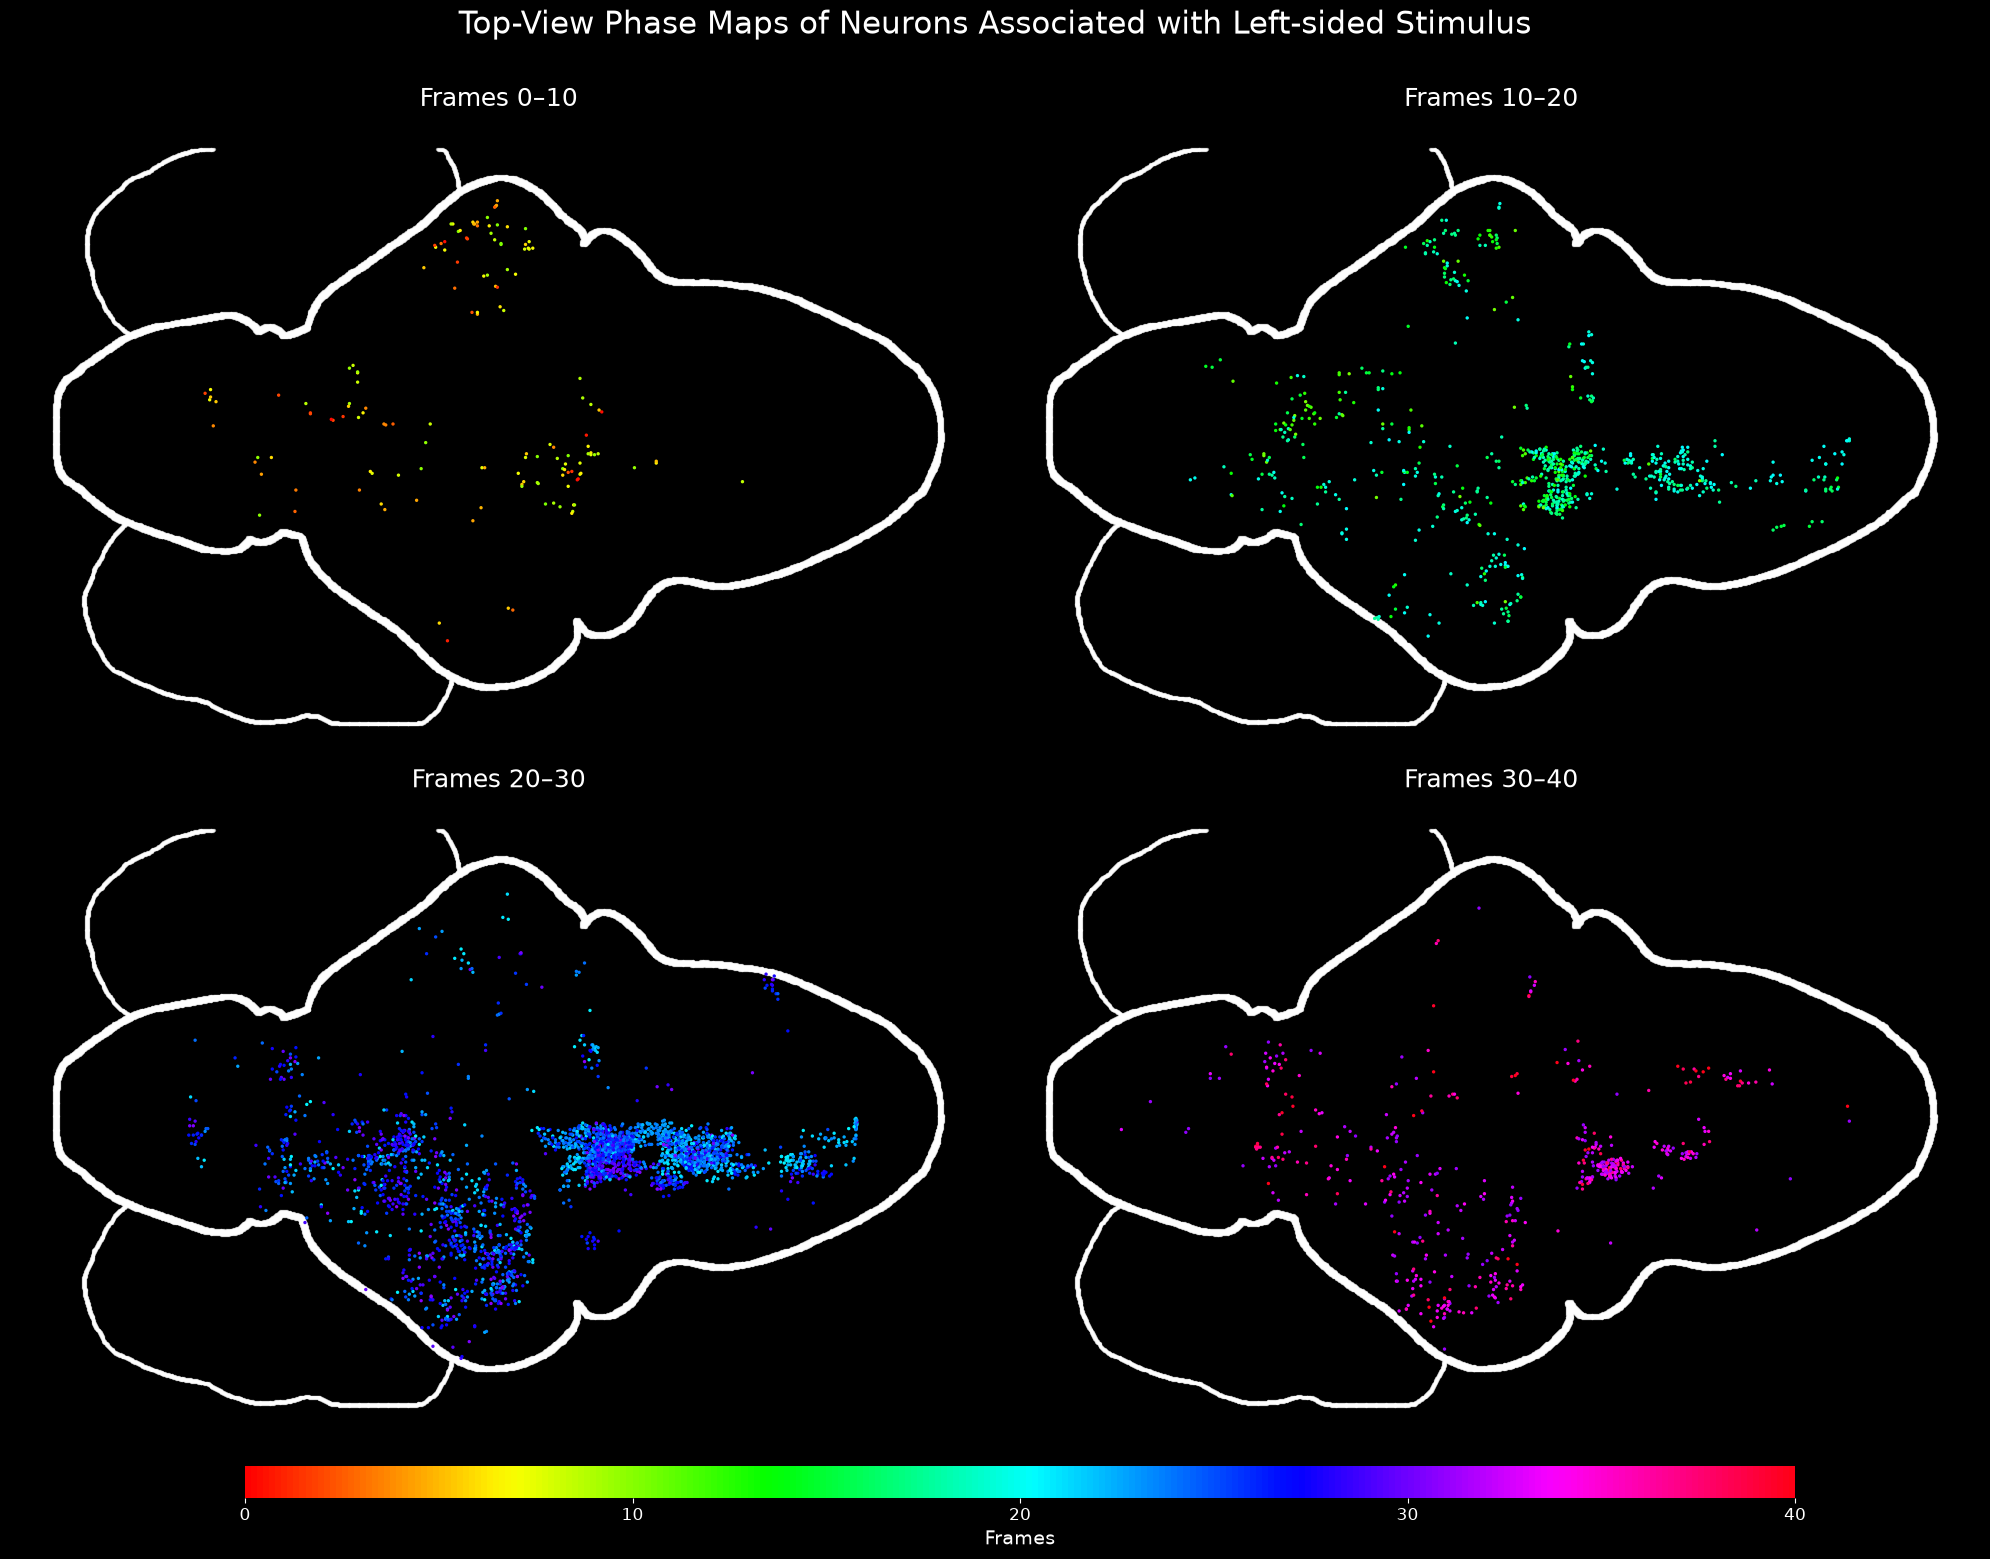

In [28]:
def ordered_phase_subplot(left_phase, left_color, phase_window, coordinate, xy_lines):
    """
    Draws 2×2 subplots showing phase-specific activation maps
    (left stimulus only), with a phase color spectrum added at the bottom.
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    fig.patch.set_facecolor('black')

    for idx, key in enumerate(phase_window.keys()):
        ax = axes[idx]
        low, high = phase_window[key]

        # Extract neuron coordinates for the left side only
        left_idx = left_phase[key]
        left_x = [coordinate[i][1][0] for i in left_idx]
        left_y = [coordinate[i][1][1] for i in left_idx]

        # --- Styling ---
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_facecolor('black')

        # --- Outline and neurons ---
        ax.scatter(xy_lines[:, 0], xy_lines[:, 1], s=2, c="white", alpha=0.5)
        ax.scatter(left_x, left_y, s=2, alpha=1, c=left_color[key])

        # --- Titles ---
        ax.set_title(f"Frames {low}–{high}", fontsize=18, pad=10, color='white')

    # --- Global title & layout ---
    fig.suptitle("Top-View Phase Maps of Neurons Associated with Left-sided Stimulus",
                 fontsize=22, y=0.95, color='white')
    plt.tight_layout(rect=[0, 0.05, 1, 0.94])

    # ---- Phase spectrum (bottom, thin bar) ----
    ax_spec = fig.add_axes([0.125, 0.02, 0.775, 0.02])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax_spec.imshow(gradient, aspect='auto', cmap='hsv', extent=[0, 40, 0, 1])
    ax_spec.set_yticks([])
    ax_spec.set_xticks([0, 10, 20, 30, 40])
    ax_spec.set_xlabel("Frames", fontsize=14, color='white')
    ax_spec.tick_params(axis='x', colors='white')
    ax_spec.set_xticklabels([0, 10, 20, 30, 40], fontsize=12, color='white')
    for spine in ax_spec.spines.values():
        spine.set_visible(False)
    ax_spec.set_facecolor('black')

    plt.show()

ordered_phase_subplot(left_phase, left_color, phase_window, coordinate, xy_lines)


The phase-grouped plots illustrate the **temporal progression** of neuronal activation across the brain during phototactic stimulation. By dividing neurons into four sequential phase windows, we can observe how distinct neural populations become active at different stages of the stimulus cycle.

This spatiotemporal organization highlights the dynamic nature of the neural response and suggests that phototactic behavior involves **coordinated, phase-dependent activation** across multiple brain regions. This analysis can be refined by **isolating neurons responsive to left-sided/right-sided stimulation**, allowing for a clearer examination of **laterality and spatial asymmetry** in the temporal activation pattern.

A more detailed interpretation of these results can be found in the **accompanying manuscript**.

## Step 5: Validating Fourier Analysis with Regression Analysis
*Corresponds to Figure 8-10 in the manuscript.*

In this section, we validate the results obtained from the **Fourier-based analysis** by comparing them with the outcomes of **regression analysis** reported in the [original *Neuron* paper](https://www.cell.com/neuron/pdf/S0896-6273(18)30844-4.pdf).

The goal is to examine whether both approaches yield similar outcomes in identifying **sensory neurons** involved in phototaxis, and to interpret any **discrepancies** between the two methods. While the Fourier analysis captures neurons whose activity contains a periodic component matching the stimulus frequency and phase, the regression method models the activity as a linear combination of stimulus regressor.


### Step 5.1: Generate stimulus regressor

To perform regression analysis, we first construct a **stimulus regressor** by convolving the binary stimulus signal with a **calcium impulse response kernel**. This kernel models the temporal dynamics of the calcium indicator following neuronal activation, characterized by an exponential decay with a half-time of **0.4 s** and a peak delay of **0.08 s**.

The resulting regressor approximates the **expected calcium signal** (ΔF/F) evoked by the stimulus, accounting for the slow rise and decay kinetics of the calcium indicator.

Run the following code block to create kernel and convolving it with the stimulus signal


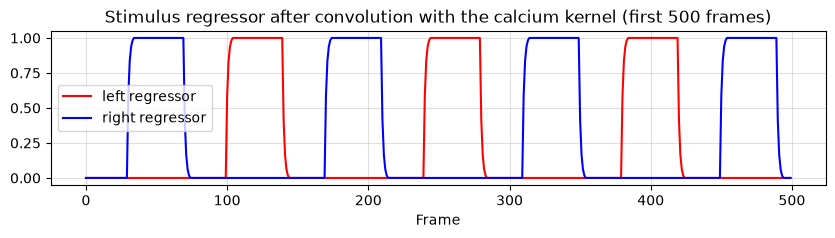

In [29]:
# Kernel modeling GCaMP6f calcium dynamics: single-exponential decay with
# half-time = 0.4 s and peak delay = 0.08 s, discretized at the dataset's nominal ~2 Hz
# imaging rate (these are the exact values used in the original analysis pipeline;
# verified against the formula in the cell below).
kernel = [0.0, 0.0, 0.0, 0.0,
          0.5875820411424945, 0.24674332653696773, 0.10373173354329597,
          0.043610339093595935, 0.018332559683645826]

stimulus_left_arr = np.array(stimulus_left, dtype=float)
stimulus_right_arr = np.array(stimulus_right, dtype=float)

# Convolve the boxcar stimulus with the calcium kernel to get the expected calcium
# response (regressor) evoked by each stimulus side.
stimulus_left_convolved = np.convolve(stimulus_left_arr, kernel, mode='same')
stimulus_right_convolved = np.convolve(stimulus_right_arr, kernel, mode='same')

plt.figure(figsize=(10, 2))
plt.plot(stimulus_left_convolved[:500], c='red', label='left regressor')
plt.plot(stimulus_right_convolved[:500], c='blue', label='right regressor')
plt.xlabel('Frame')
plt.title('Stimulus regressor after convolution with the calcium kernel (first 500 frames)')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

Where do these kernel values come from? The manuscript specifies a **single-exponential decay** with **half-time = 0.4 s** and **peak delay = 0.08 s**, but does not print the resulting discrete kernel taps. Since we use those literal values above, it is worth checking that they actually correspond to that formula before trusting the regression analysis built on top of them.

A single-exponential decay sampled every $dt$ seconds has a fixed ratio between consecutive taps: $r = 2^{-dt/\text{half\_time}}$. The peak delay (0.08 s) shifts *when* the kernel starts, but does not change this ratio between taps, so we can check it directly against the kernel above.

In [30]:
nonzero_taps = np.array(kernel[4:])
observed_ratio = (nonzero_taps[1:] / nonzero_taps[:-1]).mean()
print(f"Observed decay ratio between consecutive taps: {observed_ratio:.5f}")

half_time = 0.4  # s
for fps in (1.97, 2.0):
    dt = 1 / fps
    theoretical_ratio = 2 ** (-dt / half_time)
    print(f"  Theoretical ratio at fps={fps}: {theoretical_ratio:.5f}")

# Build a normalized 5-tap kernel from the formula at fps = 2 Hz and compare directly
fps = 2.0
r = 2 ** (-(1 / fps) / half_time)
n = np.arange(5)
theoretical_kernel = r**n / (r**n).sum()  # normalized so the kernel sums to 1

print(f"\nGiven kernel taps:       {nonzero_taps}")
print(f"Theoretical kernel taps: {theoretical_kernel}")
print(f"Max relative difference: {100 * np.max(np.abs((theoretical_kernel - nonzero_taps) / nonzero_taps)):.3f}%")

Observed decay ratio between consecutive taps: 0.42028
  Theoretical ratio at fps=1.97: 0.41494
  Theoretical ratio at fps=2.0: 0.42045

Given kernel taps:       [0.58758204 0.24674333 0.10373173 0.04361034 0.01833256]
Theoretical kernel taps: [0.58726791 0.24691574 0.10381528 0.04364895 0.01835212]
Max relative difference: 0.107%


Unlike the sharp boxcar stimulus, the regressor now has the smoother rise-and-decay shape expected of a real calcium fluorescence transient evoked by the stimulus. This is the same regressor construction described in the manuscript's Methodology section ("Identification of Stimulus-Driven Neuron by Regression analysis").

## Step 5.2: Correlate each neuron's activity with the stimulus regressor

For every neuron, we now compute the Pearson correlation coefficient between its raw activity trace and each of the two regressors (left/right). Neurons with a correlation coefficient **r > 0.5** are classified as stimulus-driven by regression — this is our validation "ground truth" (Figure 8 in the manuscript).

*This may take under a minute.*

In [31]:
regression_threshold = 0.5

regression_left = []
regression_right = []

n_neurons = len(cell_resp_z)
print(f"Running regression analysis for {n_neurons} neurons...")

for idx, (neuron_id, activity) in enumerate(cell_resp_z):
    r_left = np.corrcoef(activity, stimulus_left_convolved)[0, 1]
    r_right = np.corrcoef(activity, stimulus_right_convolved)[0, 1]
    regression_left.append([neuron_id, r_left])
    regression_right.append([neuron_id, r_right])

    if (idx + 1) % 20000 == 0 or (idx + 1) == n_neurons:
        print(f"Processed {idx + 1}/{n_neurons} neurons ({100*(idx+1)/n_neurons:.1f}%)")

regression_left = np.array(regression_left)
regression_right = np.array(regression_right)

regression_left_cleaned = regression_left[regression_left[:, 1] >= regression_threshold, 0].astype(int)
regression_right_cleaned = regression_right[regression_right[:, 1] >= regression_threshold, 0].astype(int)

print(f"\n✅ Regression analysis complete!")
print(f"Left-stimulus neurons (r > {regression_threshold}): {len(regression_left_cleaned)}")
print(f"Right-stimulus neurons (r > {regression_threshold}): {len(regression_right_cleaned)}")

Running regression analysis for 92538 neurons...


Processed 20000/92538 neurons (21.6%)


Processed 40000/92538 neurons (43.2%)


Processed 60000/92538 neurons (64.8%)


Processed 80000/92538 neurons (86.5%)


Processed 92538/92538 neurons (100.0%)

✅ Regression analysis complete!
Left-stimulus neurons (r > 0.5): 2658
Right-stimulus neurons (r > 0.5): 1056


## Step 5.3: Reproducing Figure 8 — Fourier properties of regression-identified neurons
*Corresponds to Figure 8 in the manuscript.*

To validate the Fourier approach, we now look up the **Fourier amplitude and phase** (already computed in Step 2.3, stored in `stim_locked_neuron`) for the neurons that regression analysis independently identified as stimulus-driven. If Fourier and regression agree, these neurons should land in the high-amplitude region of the amplitude-phase plane, split into two clusters aligned with the left/right stimulus windows — exactly like the manually-selected population from Step 3.

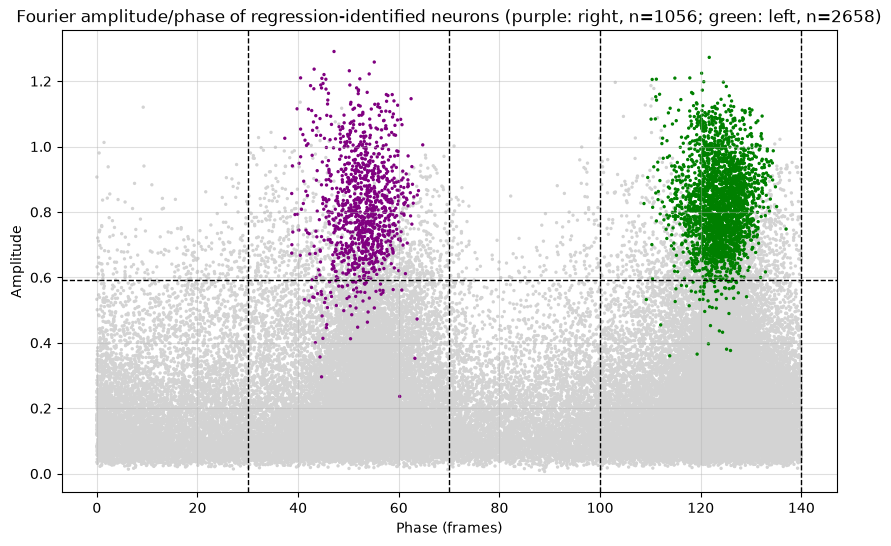

In [32]:
stim_locked_ids = stim_locked_neuron[:, 0].astype(int)

is_reg_right = np.isin(stim_locked_ids, regression_right_cleaned)
is_reg_left = np.isin(stim_locked_ids, regression_left_cleaned)

reg_color = np.where(is_reg_right, 'purple', np.where(is_reg_left, 'green', 'lightgrey'))

# Amplitude cutoff used in Step 3 (top 10%), for reference
amplitude_cutoff_value = stim_sorted[n_top - 1, 1]

# Draw grey (unselected) points first, then the regression-labeled points on top
order = np.argsort(reg_color == 'lightgrey')[::-1]  # lightgrey first, colored last (drawn on top)

plt.figure(figsize=(10, 6))
plt.grid(alpha=0.4)
plt.scatter(stim_locked_neuron[order, 2], stim_locked_neuron[order, 1], s=2, c=reg_color[order])
plt.axhline(amplitude_cutoff_value, color='black', linestyle='--', linewidth=1)
for edge in (*win_right, *win_left):
    plt.axvline(edge, color='black', linestyle='--', linewidth=1)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'Fourier amplitude/phase of regression-identified neurons '
          f'(purple: right, n={is_reg_right.sum()}; green: left, n={is_reg_left.sum()})')
plt.show()

As in Figure 8C, the regression-identified neurons (purple/green) cluster tightly in the **high-amplitude region** of the amplitude-phase plane, and separate cleanly along the phase axis into the two stimulus windows. This confirms that neurons identified as stimulus-driven by regression do carry a strong periodic component at the stimulus frequency — validating the basic premise of the Fourier approach.

### Step 5.4: Spatial map of regression-identified neurons (supplementary)

This isn't one of the manuscript's ten numbered figures, but it's a natural companion to **Figure 4** (Step 4.1): instead of mapping the Fourier-selected population, we map the neurons identified by **regression analysis** (`regression_left_cleaned` / `regression_right_cleaned` from Step 5.2) directly onto the brain, using the exact same visualization style (top/side/front views, red = left-stimulus, blue = right-stimulus, brain outline in white).

This step was originally performed in the [original *Neuron* paper](https://www.cell.com/neuron/pdf/S0896-6273(18)30844-4.pdf) that this dataset comes from, where a similar regression-based spatial map for phototaxis-related neurons can be found. Reproducing it here lets us compare the anatomical footprint of the regression-identified population directly against our own Fourier-identified population above.

Run the next four code cells to reproduce it.

In [33]:
# Reuses extract_xyz(), defined in Step 4.1, on the regression-identified neuron IDs
reg_left_x, reg_left_y, reg_left_z = extract_xyz(regression_left_cleaned, coordinate)
reg_right_x, reg_right_y, reg_right_z = extract_xyz(regression_right_cleaned, coordinate)

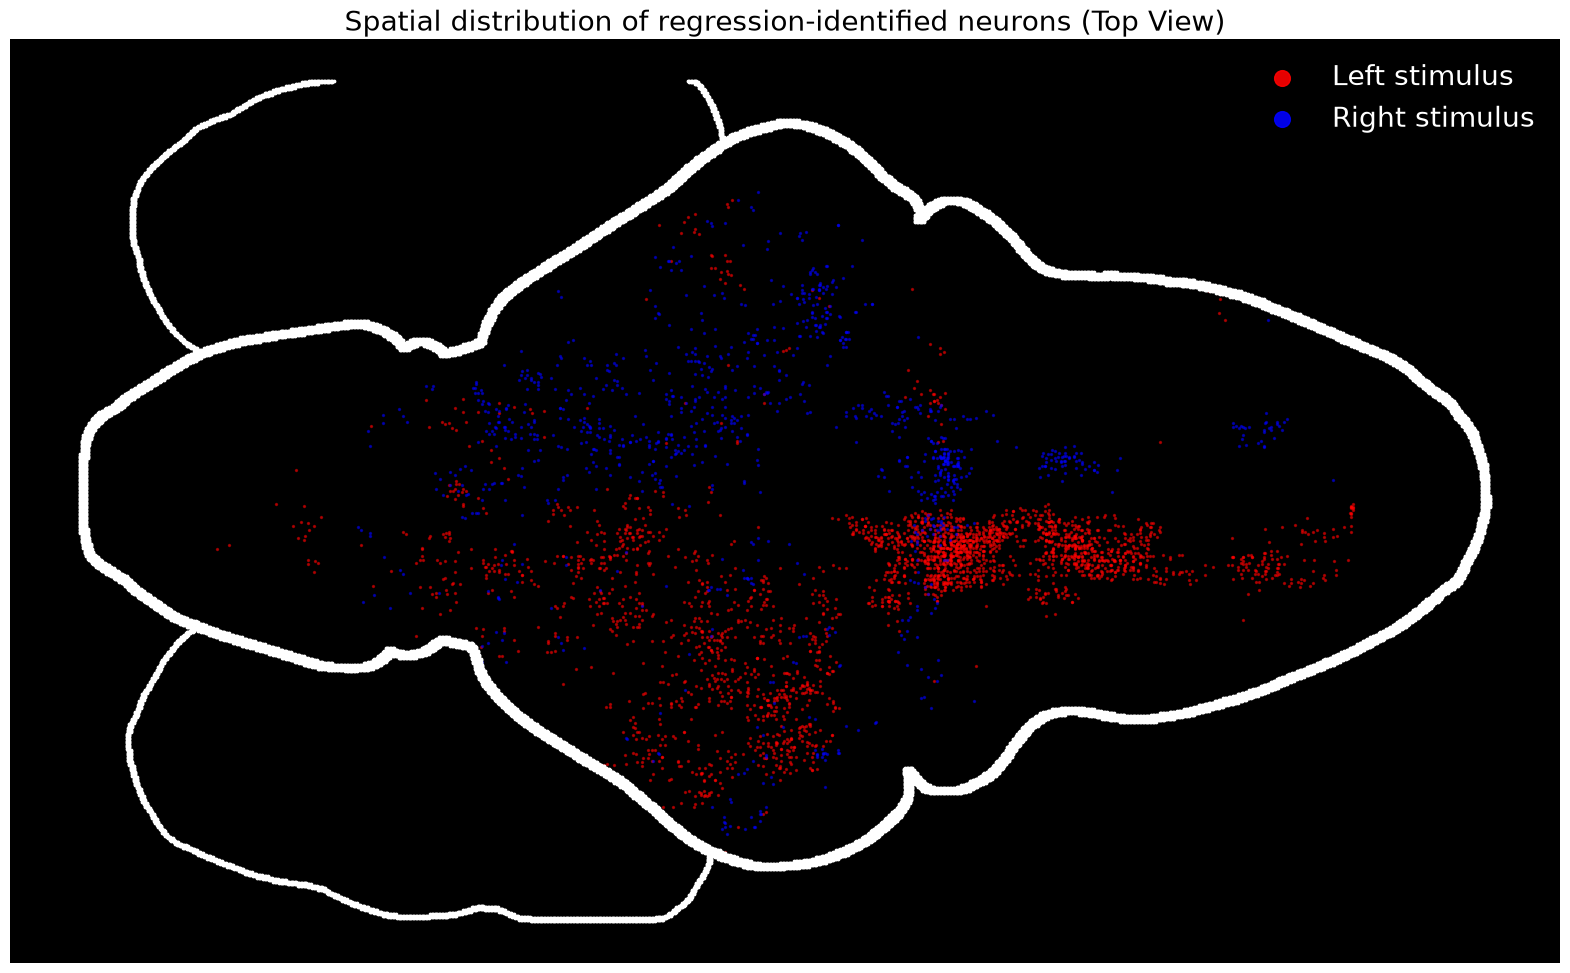

In [34]:
# Top View
plt.figure(figsize=(20, 12))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(reg_left_x, reg_left_y, s=2, alpha=0.5, c='red',  label='Left stimulus')
right_plot = plt.scatter(reg_right_x, reg_right_y, s=2, alpha=0.5, c='blue', label='Right stimulus')

# Outline
plt.scatter(xy_lines[:, 0], xy_lines[:, 1], s=3, c="white", alpha=1)

# Legend
legend = plt.legend(
    handles=[left_plot, right_plot],
    loc='upper right',
    frameon=False,
    fontsize=20,
    labelcolor='white',
    scatterpoints=1,
    markerscale=8
)
for lh in legend.legend_handles:
    lh.set_alpha(0.9)

plt.title("Spatial distribution of regression-identified neurons (Top View)", fontsize=20)
plt.show()

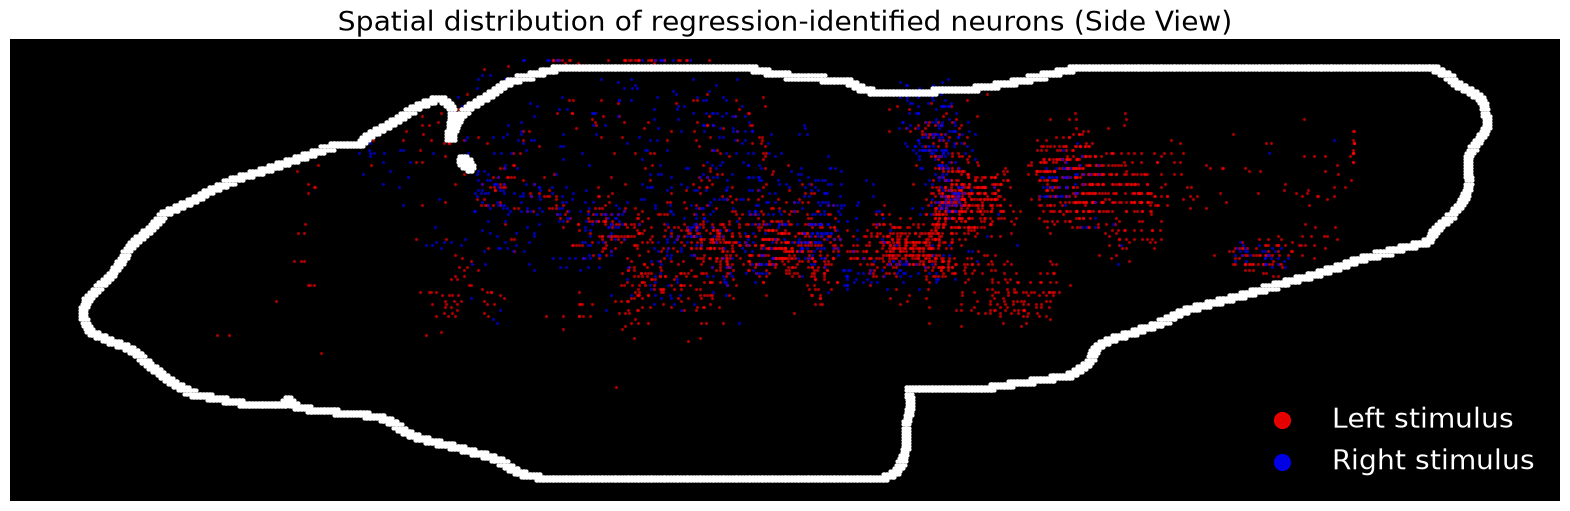

In [35]:
# Side View
plt.figure(figsize=(20, 6))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(reg_left_x, reg_left_z, s=2, alpha=0.5, c='red',  label='Left stimulus')
right_plot = plt.scatter(reg_right_x, reg_right_z, s=2, alpha=0.5, c='blue', label='Right stimulus')

# Outline
plt.scatter(yz_lines[:, 0], yz_lines[:, 1], s=4, c="white", alpha=1)

# Legend with larger color markers
legend = plt.legend(
    handles=[left_plot, right_plot],
    loc='lower right',
    frameon=False,
    fontsize=20,
    labelcolor='white',
    scatterpoints=1,
    markerscale=8
)
for lh in legend.legend_handles:
    lh.set_alpha(0.9)

plt.title("Spatial distribution of regression-identified neurons (Side View)", fontsize=20)
plt.show()

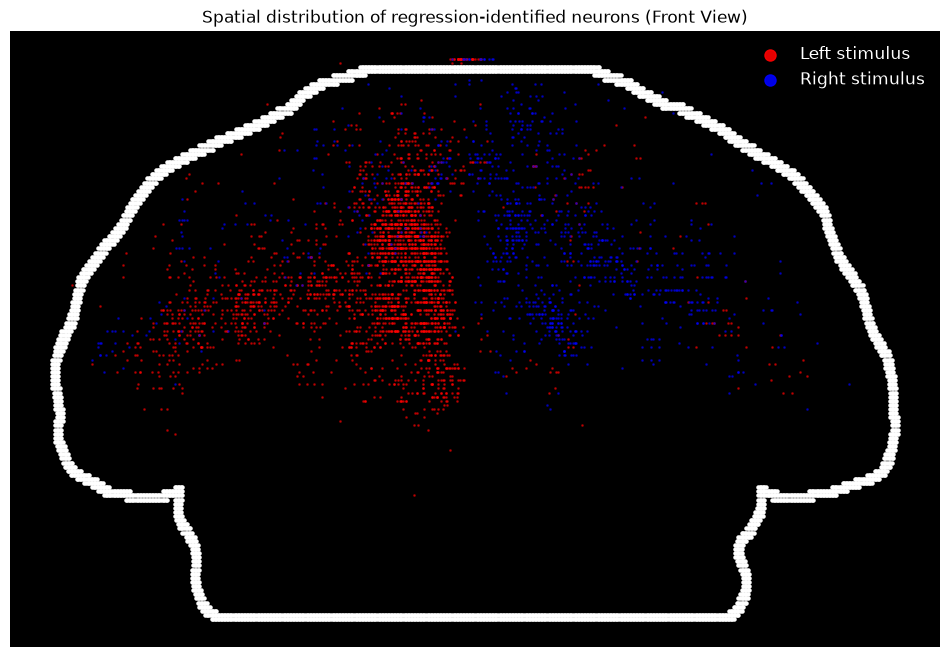

In [36]:
# Front View
plt.figure(figsize=(12, 8))
ax = plt.axes()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('black')

# Plot neurons
left_plot  = plt.scatter(reg_left_y, reg_left_z, s=1, alpha=0.5, c='red',  label='Left stimulus')
right_plot = plt.scatter(reg_right_y, reg_right_z, s=1, alpha=0.5, c='blue', label='Right stimulus')

# Outline
plt.scatter(zx_lines[:, 1], zx_lines[:, 0], s=5, c="white", alpha=1)

# Legend with larger color markers
legend = plt.legend(
    handles=[left_plot, right_plot],
    loc='upper right',
    frameon=False,
    fontsize=12,
    labelcolor='white',
    scatterpoints=1,
    markerscale=8
)
for lh in legend.legend_handles:
    lh.set_alpha(0.9)

plt.title("Spatial distribution of regression-identified neurons (Front View)", fontsize=12)
plt.show()

Visually, the regression-identified population occupies the same broad regions as the Fourier-identified map in Figure 4 (Step 4.1) — the posterior forebrain, midbrain (optic tectum), and hindbrain (anterior hindbrain oscillator) — but is noticeably **sparser**, consistent with the smaller population sizes reported in Step 5.2 (`regression_left_cleaned` / `regression_right_cleaned`) compared to the Fourier top-10%-amplitude selection. This is the same relationship quantified more precisely by the accuracy metric in Step 7 and the population-size comparison in Figure 9B: regression recovers a subset concentrated on the strongest, most stimulus-synchronized responders, while Fourier analysis additionally captures phase-shifted neurons spread across a wider anatomical footprint.

# Step 6: Comparing Fourier-Identified and Regression-Identified Neurons
*Corresponds to Figure 9 in the manuscript.*

We now directly compare the two neuron populations:
- **Fourier-identified neurons**: selected in Step 3 using the top-10% amplitude cutoff + phase window (variables `right_stimulus_neuron` / `left_stimulus_neuron`).
- **Regression-identified neurons**: selected in Step 5.2 using the correlation threshold r > 0.5 (variables `regression_left_cleaned` / `regression_right_cleaned`), with their Fourier amplitude/phase looked up from `stim_locked_neuron`.

For a fair comparison, phases are normalized relative to each neuron's associated stimulus onset (subtracting frame 30 for right-side responses, frame 100 for left-side responses), so both populations are expressed on the same 0-40 frame axis.

In [37]:
# Fourier-identified population (from Step 3/4)
fourier_right_amp = stim_sorted[phase_mask == 1][:, 1]
fourier_left_amp = stim_sorted[phase_mask == 2][:, 1]
fourier_amplitude_all = np.concatenate([fourier_right_amp, fourier_left_amp])
fourier_phase_all = np.concatenate([right_stimulus_phase, left_stimulus_phase])

# Regression-identified population, with Fourier amplitude/phase looked up from stim_locked_neuron
reg_right_amp = stim_locked_neuron[is_reg_right, 1]
reg_right_phase = stim_locked_neuron[is_reg_right, 2] - win_right[0]
reg_left_amp = stim_locked_neuron[is_reg_left, 1]
reg_left_phase = stim_locked_neuron[is_reg_left, 2] - win_left[0]
reg_amplitude_all = np.concatenate([reg_right_amp, reg_left_amp])
reg_phase_all = np.concatenate([reg_right_phase, reg_left_phase])

print(f"Fourier-identified: n = {len(fourier_amplitude_all)}")
print(f"Regression-identified (with a detectable stimulus-frequency component): n = {len(reg_amplitude_all)}")

Fourier-identified: n = 6279
Regression-identified (with a detectable stimulus-frequency component): n = 3714


### Figure 9A: Phase distribution comparison

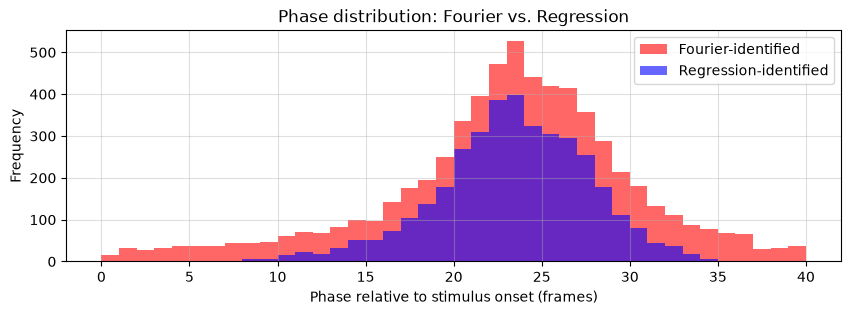

In [38]:
plt.figure(figsize=(10, 3))
plt.hist(fourier_phase_all, bins=40, range=(0, 40), color='red', alpha=0.6, label='Fourier-identified')
plt.hist(reg_phase_all, bins=40, range=(0, 40), color='blue', alpha=0.6, label='Regression-identified')
plt.xlabel('Phase relative to stimulus onset (frames)')
plt.ylabel('Frequency')
plt.title('Phase distribution: Fourier vs. Regression')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

As in Figure 9A, the regression-identified population (blue) has a **narrower** phase distribution centered near the middle of the stimulus block, while the Fourier-identified population (red) spans a **wider** range of phases — including neurons that peak near stimulus onset/offset. This reflects regression's blind spot for temporally-shifted (phase-shifted) responses that nonetheless remain periodic and stimulus-locked.

### Figure 9B: Amplitude distribution comparison

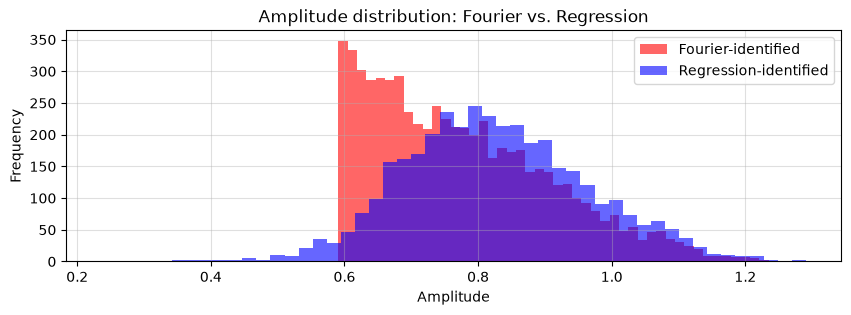

In [39]:
plt.figure(figsize=(10, 3))
plt.hist(fourier_amplitude_all, bins=50, color='red', alpha=0.6, label='Fourier-identified')
plt.hist(reg_amplitude_all, bins=50, color='blue', alpha=0.6, label='Regression-identified')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.title('Amplitude distribution: Fourier vs. Regression')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

The Fourier-identified population (red) has a hard lower edge — a direct consequence of the top-10% amplitude cutoff used for selection. The regression-identified population (blue) is not bounded this way, and includes some genuinely low-amplitude neurons that nonetheless correlate well with the stimulus regressor — a population that a pure amplitude cutoff would miss (Figure 9B in the manuscript).

### Figure 9C: Amplitude vs. regression correlation

For the Fourier-identified neurons, do stronger (higher-amplitude) responses also correlate more strongly with the stimulus regressor?

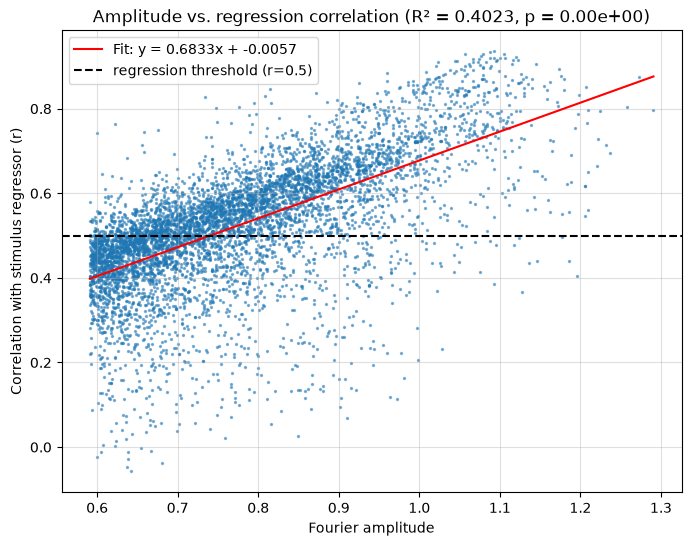

Slope: 0.6833, Intercept: -0.0057, R-squared: 0.4023, p-value: 0


In [40]:
from scipy import stats

# Look up each Fourier-identified neuron's regression correlation coefficient
reg_right_lookup = dict(zip(regression_right[:, 0].astype(int), regression_right[:, 1]))
reg_left_lookup = dict(zip(regression_left[:, 0].astype(int), regression_left[:, 1]))

fourier_selected_r = np.concatenate([
    [reg_right_lookup[i] for i in right_stimulus_neuron],
    [reg_left_lookup[i] for i in left_stimulus_neuron],
])

slope, intercept, r_value, p_value, std_err = stats.linregress(fourier_amplitude_all, fourier_selected_r)

plt.figure(figsize=(8, 6))
plt.scatter(fourier_amplitude_all, fourier_selected_r, s=2, alpha=0.5)
x_fit = np.array([fourier_amplitude_all.min(), fourier_amplitude_all.max()])
plt.plot(x_fit, intercept + slope * x_fit, color='red',
          label=f'Fit: y = {slope:.4f}x + {intercept:.4f}')
plt.axhline(regression_threshold, color='black', linestyle='--', label=f'regression threshold (r={regression_threshold})')
plt.xlabel('Fourier amplitude')
plt.ylabel('Correlation with stimulus regressor (r)')
plt.title(f'Amplitude vs. regression correlation (R² = {r_value**2:.4f}, p = {p_value:.2e})')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R-squared: {r_value**2:.4f}, p-value: {p_value:.4g}")

There is a significant positive relationship between a neuron's Fourier amplitude and its correlation with the stimulus regressor — consistent with Figure 9C in the manuscript (which reports R² = 0.40, p < 0.001). Higher-amplitude periodic responses tend to track the stimulus more closely, but the relationship is far from perfect: many high-amplitude, strongly periodic neurons still fall below the regression threshold.

### Figure 9D: Regression value distribution of Fourier-identified neurons

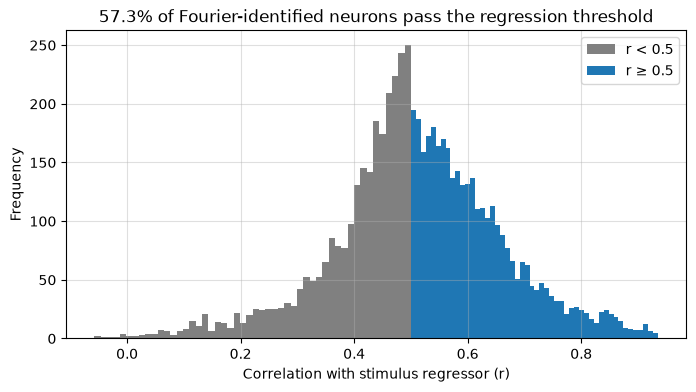

In [41]:
above_thresh = fourier_selected_r >= regression_threshold

plt.figure(figsize=(8, 4))
plt.hist(fourier_selected_r[~above_thresh], bins=50, color='grey', label=f'r < {regression_threshold}')
plt.hist(fourier_selected_r[above_thresh], bins=50, color='tab:blue', label=f'r ≥ {regression_threshold}')
plt.xlabel('Correlation with stimulus regressor (r)')
plt.ylabel('Frequency')
plt.title(f'{100*above_thresh.mean():.1f}% of Fourier-identified neurons pass the regression threshold')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

As reported in the manuscript, roughly half of the Fourier-identified neurons fall below the conventional regression threshold. These "subthreshold" neurons are not noise — they show strong, precisely frequency-locked periodic activity (which is why Fourier analysis selected them), just with a temporal profile that doesn't closely track the stimulus regressor's shape. This is the central argument for Fourier analysis as a *complementary* — not a replacement — tool alongside regression.

# Step 7: Accuracy of Fourier Analysis Across Amplitude Cutoffs
*Corresponds to Figure 10 in the manuscript.*

The top-10% amplitude cutoff used throughout this notebook was not arbitrary — it was chosen by sweeping a range of cutoff values and measuring how well the resulting Fourier-identified population overlaps with the regression-identified "ground truth" population. The validation metric, as defined in the manuscript, is:

$$\text{Accuracy} = \frac{|A \cap B|}{|B|} \times 100\%$$

where $A$ is the set of neurons selected by the Fourier pipeline at a given cutoff, and $B$ is the fixed set of regression-identified neurons (r > 0.5).

We reproduce this sweep (cutoffs from 1% to 25%) for our example fish below. Note: the manuscript's Figure 10 averages this curve across all **10** zebrafish in the dataset; reproducing that fully requires downloading each fish's imaging data separately (~1 GB+ each). See `demo/multi_fish_accuracy.py` for a script that extends this exact analysis across all 10 fish once their data has been downloaded.

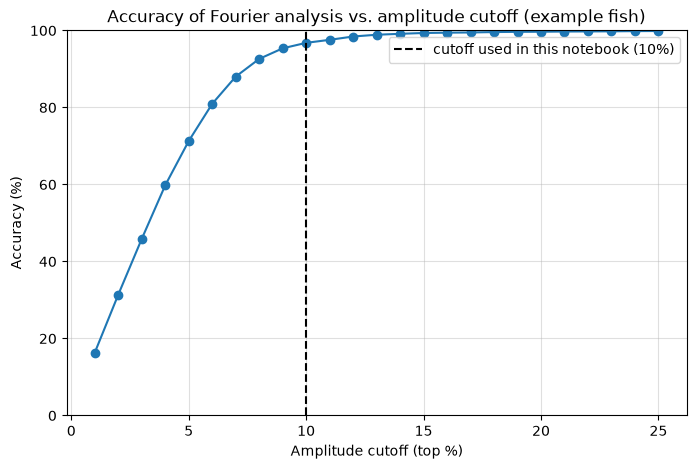

Accuracy at the 10% cutoff used throughout this notebook: 96.8%


In [42]:
cutoffs = np.arange(0.01, 0.26, 0.01)
regression_all_cleaned = set(regression_left_cleaned.tolist()) | set(regression_right_cleaned.tolist())

accuracies = []
for c in cutoffs:
    n_c = int(n_total * c)
    top_c = stim_sorted[:n_c]
    phases_c = top_c[:, 2]
    ids_c = top_c[:, 0].astype(int)

    in_right = (phases_c >= win_right[0]) & (phases_c <= win_right[1])
    in_left = (phases_c >= win_left[0]) & (phases_c <= win_left[1])
    selected_ids = set(ids_c[in_right | in_left].tolist())

    overlap = len(selected_ids & regression_all_cleaned)
    accuracies.append(100 * overlap / len(regression_all_cleaned))

plt.figure(figsize=(8, 5))
plt.plot(cutoffs * 100, accuracies, marker='o')
plt.axvline(10, color='black', linestyle='--', label='cutoff used in this notebook (10%)')
plt.xlabel('Amplitude cutoff (top %)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy of Fourier analysis vs. amplitude cutoff (example fish)')
plt.legend()
plt.grid(alpha=0.4)
plt.ylim(0, 100)
plt.show()

print(f"Accuracy at the 10% cutoff used throughout this notebook: {accuracies[9]:.1f}%")

As in Figure 10, accuracy rises steeply for very small cutoffs (where only the strongest, most unambiguous responders are selected) and plateaus as the cutoff grows and the Fourier-selected population approaches full coverage of the regression-identified neurons. The 10% cutoff used throughout this notebook sits past the steepest part of the curve, balancing high accuracy against a reasonably complete population — consistent with the manuscript's reported ~83% average accuracy across fish (95% in their example fish).

# Summary

This notebook reproduced the full Fourier-based analysis pipeline described in the manuscript, end to end, on one example zebrafish (Fish 6):

| Notebook section | Manuscript figure(s) |
|---|---|
| Step 1: Stimulus periodicity | Figure 1A |
| Step 2: DFT of neuron activity, sinusoidal approximation | Figure 1B, Figure 2 |
| Step 3: Amplitude/phase selection criteria | Figure 3 |
| Step 4: Spatial and phase mapping | Figures 4-7 |
| Step 5: Regression analysis & Fourier properties of regression-identified neurons | Figure 8 |
| Step 6: Fourier vs. regression comparison | Figure 9 |
| Step 7: Accuracy across amplitude cutoffs | Figure 10 |

**Key takeaways**, matching the manuscript's Discussion:
- Fourier analysis extracts three biologically meaningful parameters from a periodic signal — **frequency**, **amplitude**, and **phase** — directly from each neuron's activity trace.
- Neurons identified by regression analysis are almost entirely a *subset* of the high-amplitude, phase-aligned population found by Fourier analysis, validating the approach.
- Fourier analysis additionally captures **phase-shifted neurons** — with transient onset/offset activity — that regression analysis systematically misses, because their temporal profile doesn't match the stimulus regressor even though they are strongly and precisely locked to the stimulus frequency.
- The approach requires periodic stimulation, limiting it to appropriate experimental paradigms, but is a powerful complement to regression wherever that requirement is met.

**Next steps:**
- To extend this analysis across the full 10-fish dataset (as in Figures 4 and 10 of the manuscript), see `demo/multi_fish_accuracy.py`.
- To review the underlying Fourier mathematics from first principles, see `Intro_Fourier_Transformation.ipynb`.